# Warehouse CNN to SNN (Akida v1) — Kaggle Pipeline v3
**Author:** Aftab Hussain | JKU Linz — SNN-NeuroEdge / FedSNN
**Pipeline:** GPU CNN training → 8/4/4 quantization → force 1-bit spike → Akida v1 → `.fbz`
**Verified stack:** Python 3.12 | TF 2.19.1 | tf-keras 2.19.0 | Akida 2.19.1 | CNN2SNN 2.19.1

---
**v3 critical fixes vs v1/v2:**
- Uses `cnn2snn.quantize()` + `cnn2snn.quantize_layer()` API (matches the working local pipeline)
- Explicitly forces `spike_relu` to 1-bit and `tmp_logits` to 2-bit via `quantize_layer()`
- Rescaling(1/255) kept inside model — `cnn2snn.quantize()` handles it correctly via input_weight_quantization=8
- This produces `tmp_logits input_bits=1` in the FBZ, which is mandatory for AkidaUnsupervised

**Confirmed working FBZ signature:**
```
[4] spike_conv7   out=[1,1,256]  input_bits=4  output_signed=False
[5] tmp_logits    out=[1,1,5]    input_bits=1  output_signed=True
compile() → SUCCESS
```

---
**BEFORE RUNNING:**
1. Set runtime: `Runtime → Change runtime type → GPU T4 x2`
2. Attach dataset: `+ Add Data → Your Datasets → Warehouse Dataset`
3. Verify `DATA_ROOT` in Cell 5 matches your dataset mount path
4. Run Cell 1 → Cell 2 → **Restart Session** → Cell 3 onwards

## Cell 1 — Verify GPU

In [ ]:
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout if result.returncode == 0 else
      'No GPU detected — go to Runtime → Change runtime type → GPU T4 x2')

## Cell 2 — Install Akida Stack
> Run this cell, then **Restart Session**, then continue from Cell 3.
>
> **Why cnn2snn API (not QuantizeML)?**
> The `cnn2snn.quantize()` + `cnn2snn.quantize_layer()` API correctly produces
> 1-bit binary spike outputs when you call `quantize_layer(model, "spike_relu", 1)`.
> The QuantizeML API does NOT reliably force 1-bit on the spike layer,
> which causes `AkidaUnsupervised` to fail on hardware with
> "Only layers receiving binary inputs can be trained".

In [ ]:
# ================================================================
# Cell 2 — Install (confirmed working stack)
#   TF 2.19.1 | tf-keras 2.19.0 | akida 2.19.1 | cnn2snn 2.19.1
# ================================================================

!pip uninstall -y tensorflow tensorflow-cpu tensorflow-gpu \
                   tensorflow-io-gcs-filesystem \
                   keras keras-core keras-nightly tf-keras keras-hub \
                   tensorboard tensorboard-data-server tensorflow-estimator \
                   cnn2snn akida quantizeml 2>/dev/null || true

!pip cache purge

# tf-keras shim must be installed before Akida packages
!pip install -q 'tf-keras==2.18.0'

# akida + cnn2snn from BrainChip Artifactory
!pip install -q \
    --extra-index-url https://brainchip.jfrog.io/artifactory/api/pypi/pypi-akida/simple \
    'akida==2.19.1' \
    'cnn2snn==2.19.1'

!pip install -q scikit-learn

print('=' * 60)
print('Installation complete.')
print('>>> MANDATORY: Runtime → Restart Session, then run Cell 3.')
print('=' * 60)

## Cell 3 — Verify Versions (run after kernel restart)
> CUDA/cuDNN factory warnings are harmless.

In [1]:
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'

import tensorflow as tf
import tf_keras
import akida
import cnn2snn

print(f'Python     : {__import__("sys").version}')
print(f'TensorFlow : {tf.__version__}')
print(f'tf_keras   : {tf_keras.__version__}')
print(f'Akida      : {akida.__version__}')
print(f'CNN2SNN    : {cnn2snn.__version__}')

# Verify the quantize + quantize_layer API is available
from cnn2snn import convert, set_akida_version, AkidaVersion, quantize, quantize_layer
print('\ncnn2snn symbols OK: convert, set_akida_version, AkidaVersion, quantize, quantize_layer')

gpus = tf.config.list_physical_devices('GPU')
print(f'\nGPUs: {gpus}')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    print('GPU memory growth enabled.')
else:
    print('WARNING: No GPU — go to Runtime → Change runtime type → GPU T4')

from akida import devices
print(f'Akida devices (expect []): {[str(d) for d in devices()]}')
print('\n=== All checks passed — ready to train ===')

2026-03-19 16:37:35.184136: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773938255.205553     165 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773938255.212001     165 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773938255.229213     165 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773938255.229234     165 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773938255.229237     165 computation_placer.cc:177] computation placer alr

Python     : 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
TensorFlow : 2.19.1
tf_keras   : 2.19.0
Akida      : 2.19.1
CNN2SNN    : 2.19.1

cnn2snn symbols OK: convert, set_akida_version, AkidaVersion, quantize, quantize_layer

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU memory growth enabled.
Akida devices (expect []): []

=== All checks passed — ready to train ===


## Cell 4 — All Imports

In [2]:
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'

import glob, math, random, json, warnings, time, collections
warnings.filterwarnings('ignore')

import numpy as np
from pathlib import Path
import tensorflow as tf
import tf_keras
from tf_keras import Model, layers, optimizers, losses, callbacks
from tensorflow.data import Dataset

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator
import PIL.Image as PILImage
from IPython.display import Image as IPImage, display

from sklearn.metrics import (
    precision_recall_fscore_support,
    classification_report
)

import akida
from akida import devices
import cnn2snn
from cnn2snn import convert, set_akida_version, AkidaVersion, quantize, quantize_layer

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

ncpu = os.cpu_count() or 4
tf.config.threading.set_intra_op_parallelism_threads(ncpu)
tf.config.threading.set_inter_op_parallelism_threads(min(4, ncpu))
AUTOTUNE = tf.data.AUTOTUNE

print(f'All imports OK | CPUs: {ncpu} | GPU: {tf.config.list_physical_devices("GPU")}')

All imports OK | CPUs: 4 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Cell 5 — Configuration + Publication Style
> Update `DATA_ROOT` to match your Kaggle dataset mount path.
> Run Cell 5b first if unsure.

In [3]:
# ---------------------------------------------------------------
# Dataset
# ---------------------------------------------------------------
DATA_ROOT = Path('/kaggle/input/datasets/aftabhussaincui/warehouse-objects-dataset/Warehouse')
CLASSES   = ['boxes_stacked', 'empty_aisle', 'forklift_present',
             'mixed_objects', 'unclear_scene']
CLASS_LABELS = ['Boxes\nStacked', 'Empty\nAisle', 'Forklift\nPresent',
                'Mixed\nObjects', 'Unclear\nScene']

# ---------------------------------------------------------------
# Mode toggle
# FAST_MODE=True  → quick iteration (160x160, 256ch, 15 epochs, capped dataset)
# FAST_MODE=False → full paper run (160x160, 256ch, 30 epochs, full dataset)
#
# IMPORTANT: Always use IMG_SIZE=(160,160) and SPK_CH=256.
# These are locked to the hardware-verified working configuration.
# Do NOT change to 224x224 or 512 channels without re-testing on hardware.
# ---------------------------------------------------------------
FAST_MODE            = False   # False = full training for paper
IMG_SIZE             = (160, 160)   # locked — hardware verified
SPK_CH               = 256          # locked — hardware verified
EPOCHS               = 15 if FAST_MODE else 30
MAX_TRAIN_PER_CLASS  = 2000   # only used in FAST_MODE
MAX_VAL_PER_CLASS    = 400    # only used in FAST_MODE
MAX_STEPS_PER_EPOCH  = None

# ---------------------------------------------------------------
# Hyperparameters
# ---------------------------------------------------------------
BATCH_SIZE          = 32
RESERVE_PER_CLASS   = 200
TRAIN_VAL_SPLIT     = 0.90
EARLY_STOP_PATIENCE = 8
CACHE_DATA          = False
CACHE_PREFIX        = '.tf_cache'

# ---------------------------------------------------------------
# Output paths
# ---------------------------------------------------------------
OUTPUT_DIR          = Path('/kaggle/working/results')
OUTPUT_DIR.mkdir(exist_ok=True)

FBZ_OUT             = '/kaggle/working/warehouse_edge_backbone_full.fbz'
BEST_H5             = '/kaggle/working/warehouse_model_backbone_best.h5'
FINAL_H5            = '/kaggle/working/warehouse_model_backbone_final.h5'
QUANT_H5            = '/kaggle/working/warehouse_model_quantized.h5'
HISTORY_JSON        = str(OUTPUT_DIR / 'train_history.json')
METRICS_JSON        = str(OUTPUT_DIR / 'val_metrics.json')
RESERVED_PATHS_JSON = '/kaggle/working/reserved_paths.json'

def fig_paths(name):
    return str(OUTPUT_DIR / f'{name}.png'), str(OUTPUT_DIR / f'{name}.eps')

# ---------------------------------------------------------------
# Publication-quality matplotlib style (IEEE / Nature)
# ---------------------------------------------------------------
def set_pub_style():
    plt.rcParams.update({
        'font.family'        : 'serif',
        'font.serif'         : ['Times New Roman', 'DejaVu Serif'],
        'font.size'          : 9,
        'axes.titlesize'     : 10,
        'axes.labelsize'     : 9,
        'xtick.labelsize'    : 8,
        'ytick.labelsize'    : 8,
        'legend.fontsize'    : 8,
        'legend.title_fontsize': 8,
        'lines.linewidth'    : 1.5,
        'lines.markersize'   : 4,
        'patch.linewidth'    : 0.8,
        'axes.linewidth'     : 0.8,
        'axes.spines.top'    : False,
        'axes.spines.right'  : False,
        'axes.grid'          : True,
        'axes.grid.axis'     : 'y',
        'grid.linewidth'     : 0.4,
        'grid.alpha'         : 0.4,
        'grid.linestyle'     : '--',
        'xtick.direction'    : 'out',
        'ytick.direction'    : 'out',
        'xtick.major.width'  : 0.8,
        'ytick.major.width'  : 0.8,
        'xtick.major.size'   : 3,
        'ytick.major.size'   : 3,
        'legend.frameon'     : True,
        'legend.framealpha'  : 0.9,
        'legend.edgecolor'   : '0.8',
        'legend.fancybox'    : False,
        'figure.dpi'         : 300,
        'savefig.dpi'        : 300,
        'savefig.bbox'       : 'tight',
        'savefig.pad_inches' : 0.05,
        'figure.facecolor'   : 'white',
        'axes.facecolor'     : 'white',
    })

def save_fig(fig, name):
    png_path, eps_path = fig_paths(name)
    fig.savefig(png_path, dpi=300, bbox_inches='tight', facecolor='white')
    try:
        fig.savefig(eps_path, format='eps', bbox_inches='tight')
    except Exception:
        pass
    print(f'  Saved: {png_path}')
    plt.close(fig)

# Wong (2011) colorblind-safe palette
PALETTE = {
    'train'   : '#0072B2',
    'val'     : '#E69F00',
    'float'   : '#0072B2',
    'quant'   : '#E69F00',
    'snn'     : '#009E73',
    'neutral' : '#56B4E9',
    'accent'  : '#D55E00',
    'gray'    : '#999999',
}
CLASS_COLORS = ['#0072B2', '#E69F00', '#009E73', '#D55E00', '#CC79A7']

set_pub_style()
print(f'FAST_MODE={FAST_MODE} | IMG_SIZE={IMG_SIZE} | SPK_CH={SPK_CH} | EPOCHS={EPOCHS}')
print(f'Output dir: {OUTPUT_DIR}')
print('Configuration OK.')

FAST_MODE=False | IMG_SIZE=(160, 160) | SPK_CH=256 | EPOCHS=30
Output dir: /kaggle/working/results
Configuration OK.


## Cell 5b — Dataset Path Diagnostic

In [4]:
print('=== /kaggle/input contents ===')
input_root = Path('/kaggle/input')
if input_root.exists():
    for item in sorted(input_root.iterdir()):
        print(f'  {item}')
        if item.is_dir():
            for sub in sorted(item.iterdir()):
                n = len(list(sub.glob('*'))) if sub.is_dir() else ''
                print(f'      ---- {sub.name}/  ({n} items)' if sub.is_dir()
                      else f'      ---- {sub.name}')
else:
    print('  /kaggle/input does not exist!')

print(f'\n=== Checking DATA_ROOT: {DATA_ROOT} ===')
if DATA_ROOT.exists():
    for c in CLASSES:
        p = DATA_ROOT / c
        imgs = []
        for ext in ['*.jpg', '*.jpeg', '*.png', '*.bmp']:
            imgs.extend(glob.glob(str(p / ext)))
        status = 'OK' if len(imgs) > 0 else 'MISSING'
        print(f'  {status}  {c:<25}: {len(imgs)} images')
else:
    print(f'  DATA_ROOT not found: {DATA_ROOT}')
    print('  Update DATA_ROOT in Cell 5 to match the path shown above.')

=== /kaggle/input contents ===
  /kaggle/input/datasets
      ---- aftabhussaincui/  (1 items)

=== Checking DATA_ROOT: /kaggle/input/datasets/aftabhussaincui/warehouse-objects-dataset/Warehouse ===
  OK  boxes_stacked            : 2548 images
  OK  empty_aisle              : 3795 images
  OK  forklift_present         : 1100 images
  OK  mixed_objects            : 3496 images
  OK  unclear_scene            : 2248 images


## Cell 6 — Dataset Visualization

  boxes_stacked            :  2548 images
  empty_aisle              :  3795 images
  forklift_present         :  1100 images
  mixed_objects            :  3496 images
  unclear_scene            :  2248 images

  Total: 13187 | Reserve: 200/class = 1000 total


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


  Saved: /kaggle/working/results/fig1_dataset_stats.png


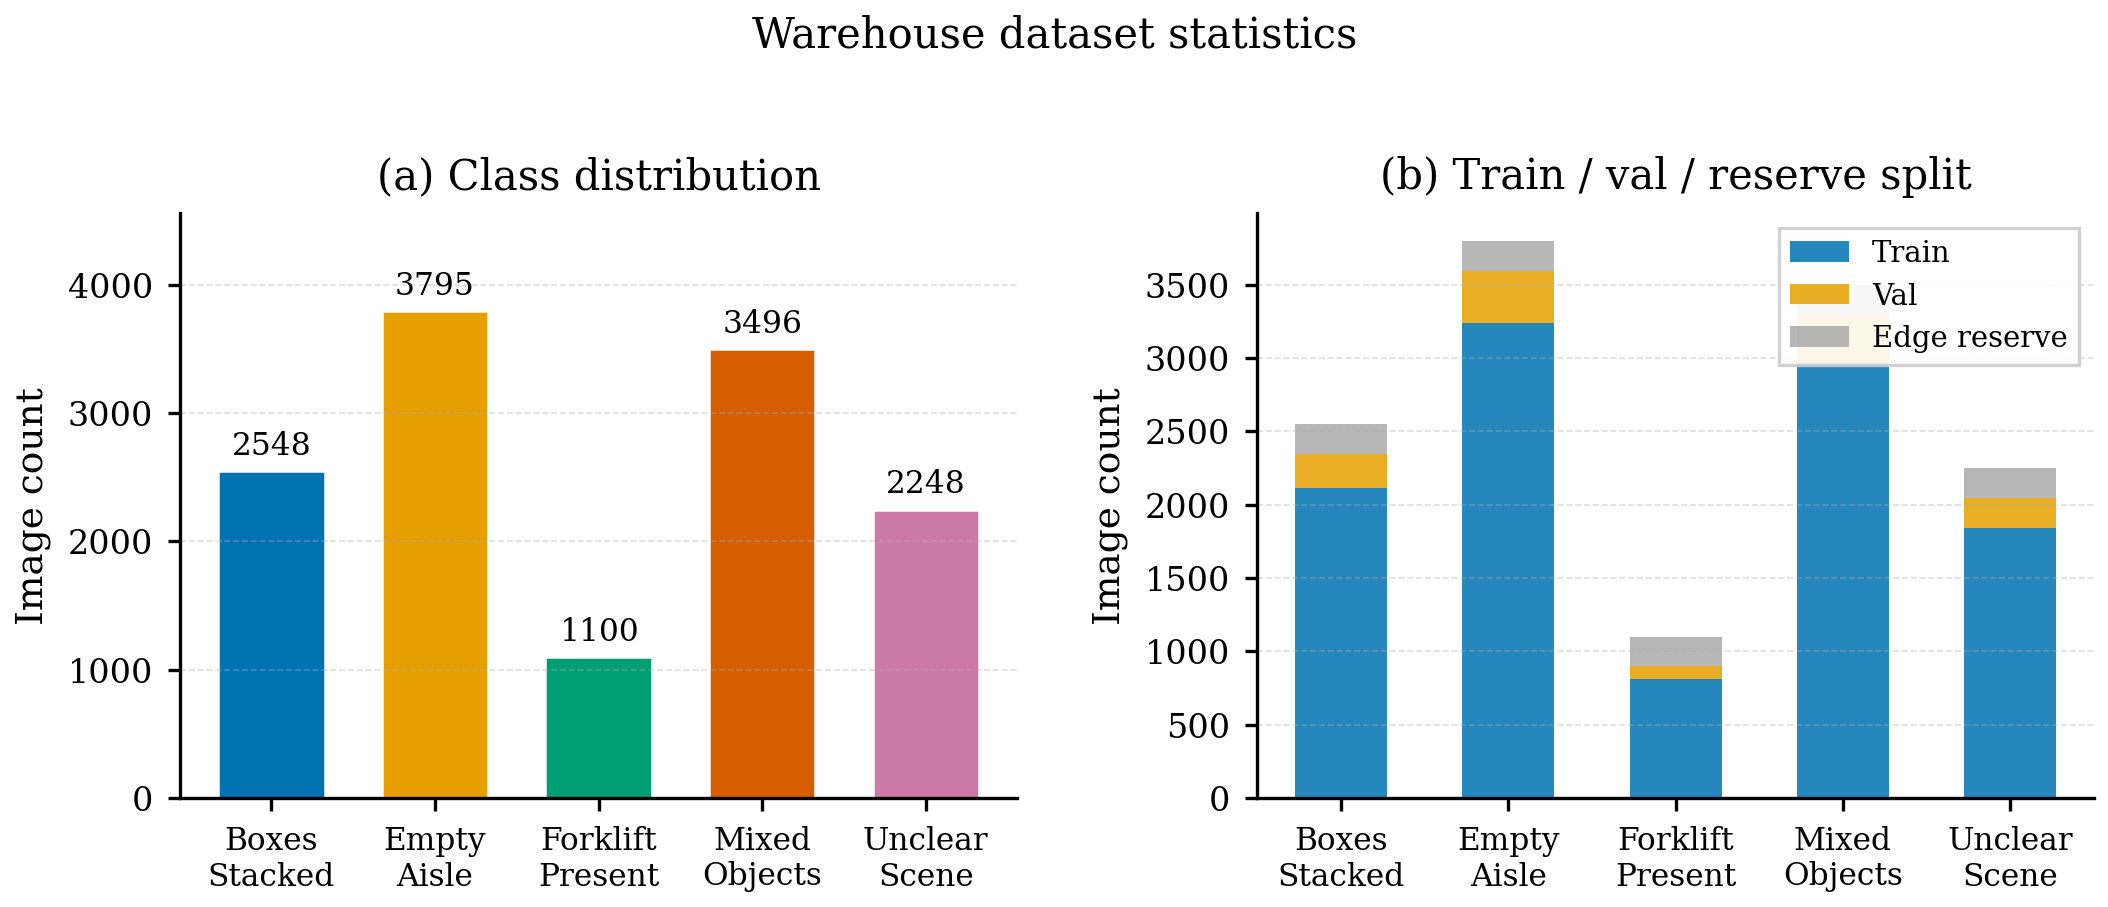

  Saved: /kaggle/working/results/fig2_sample_images.png


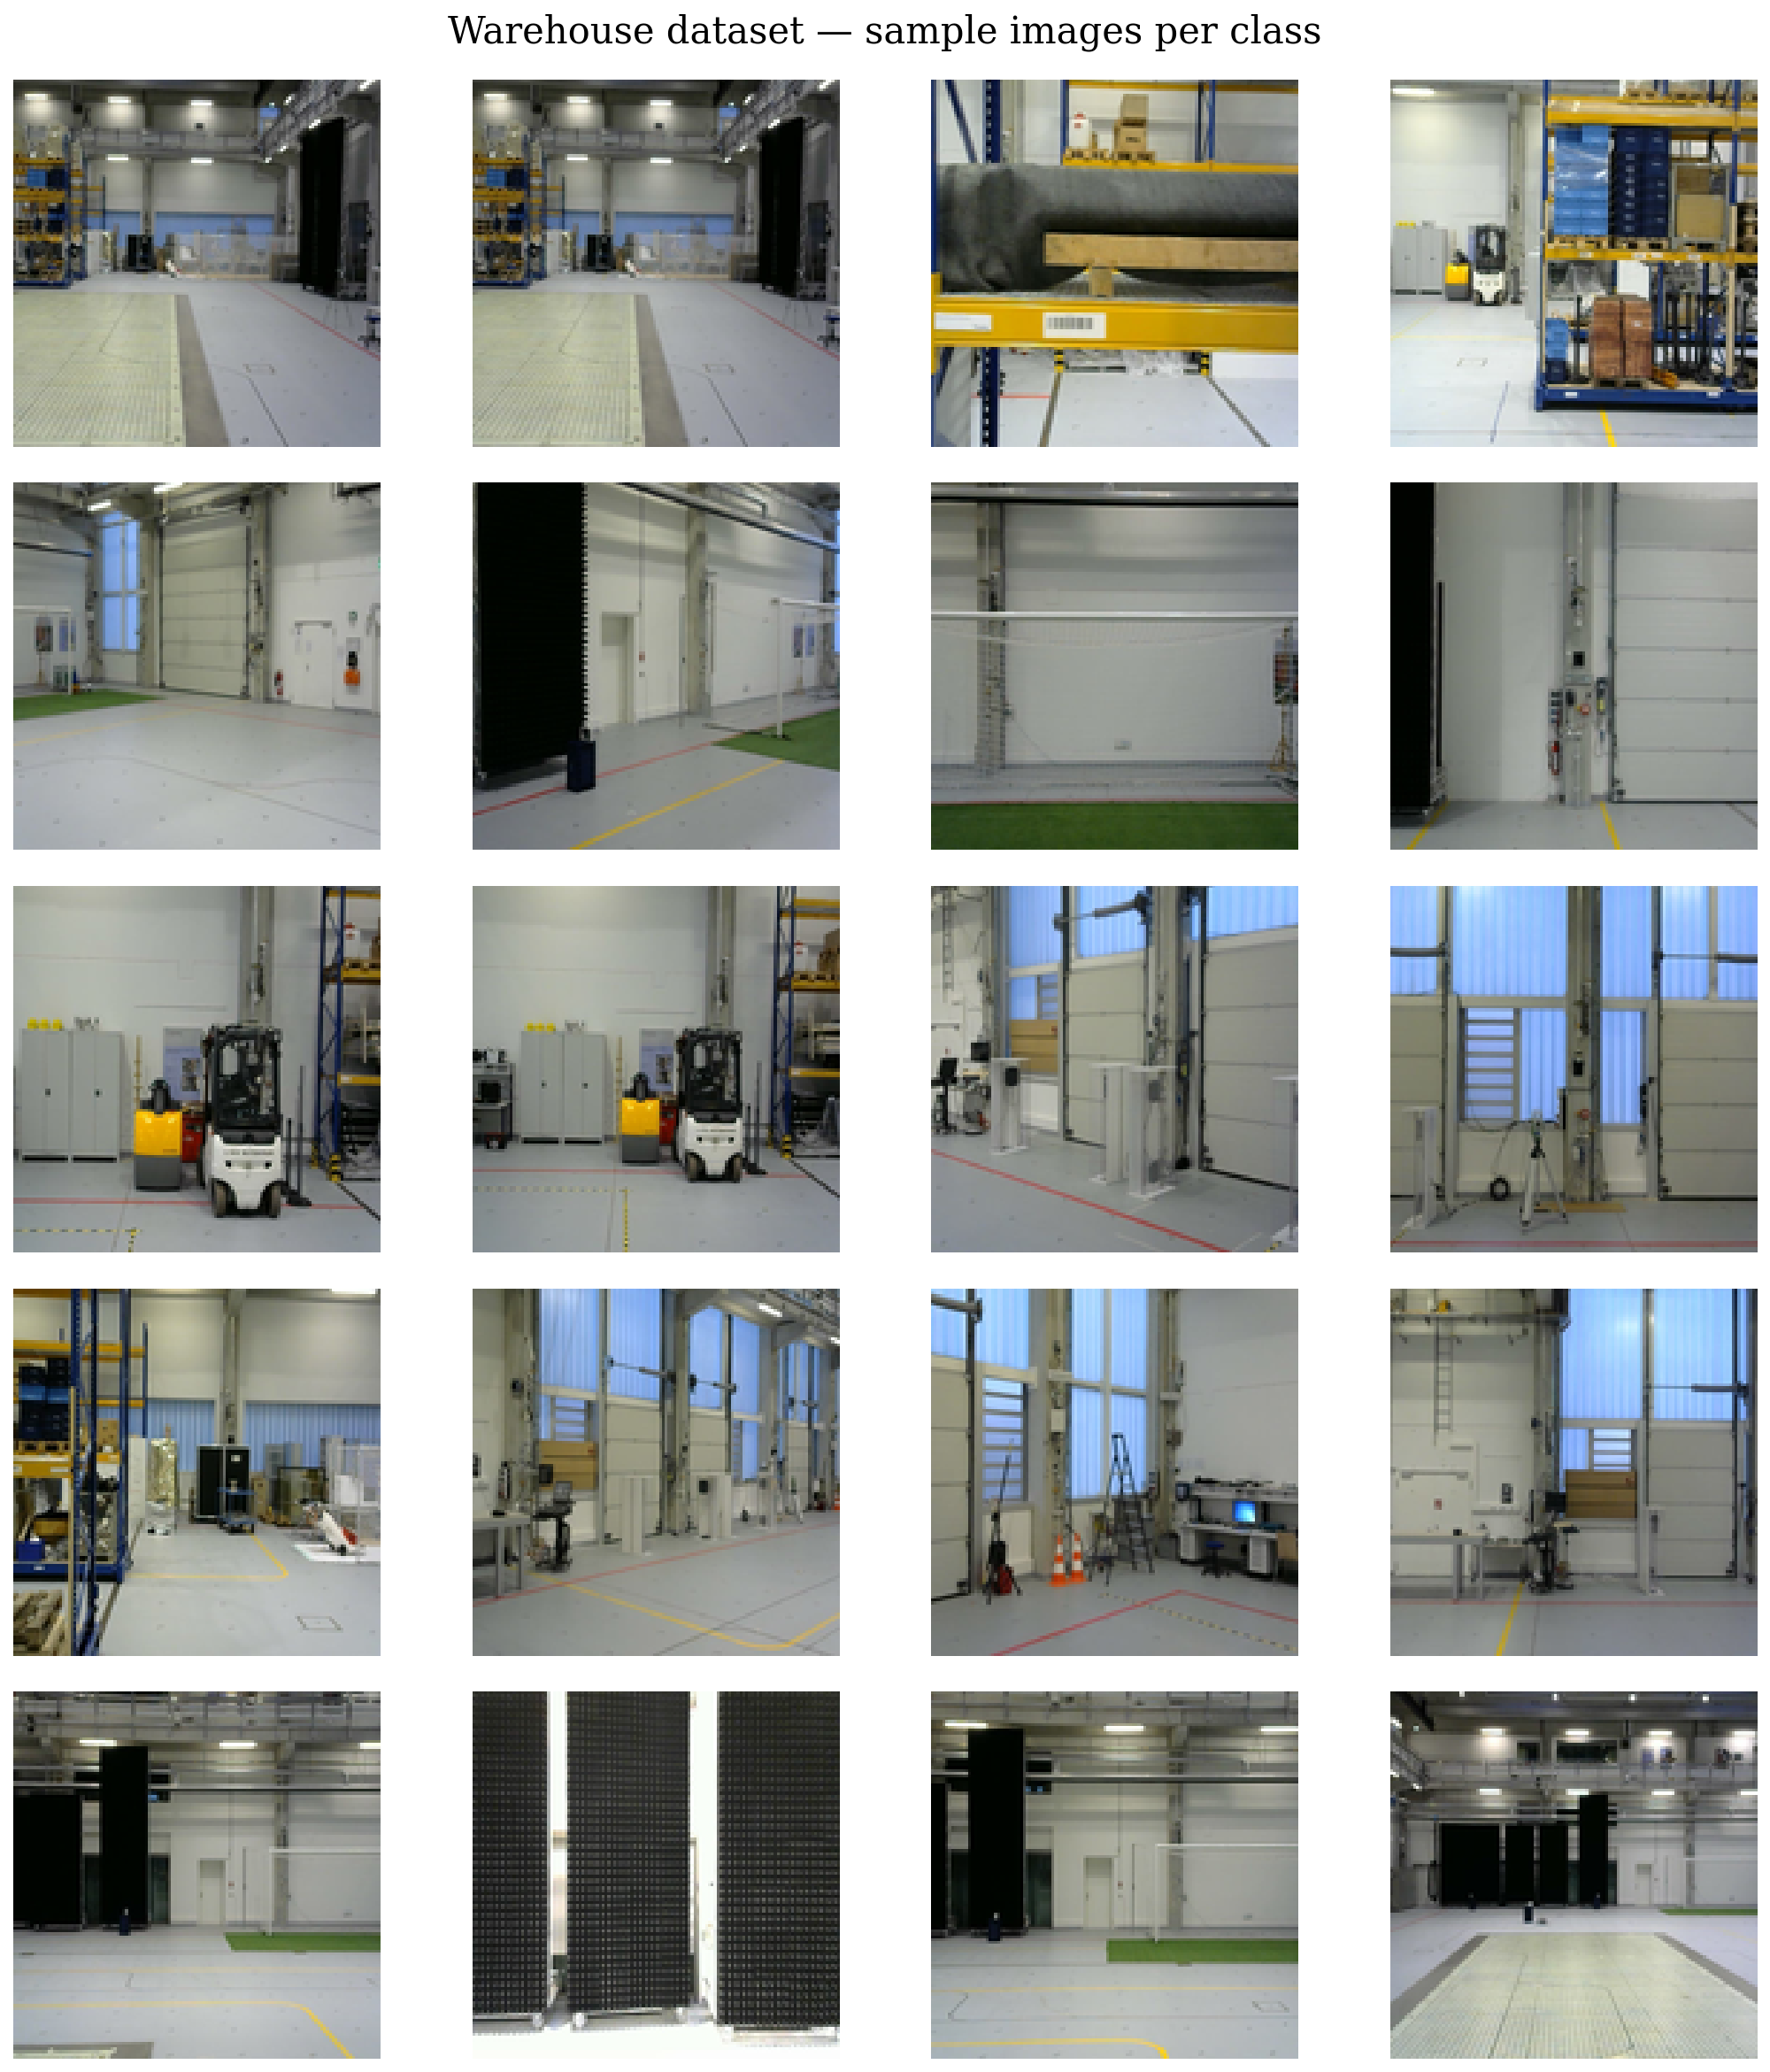

In [5]:
assert DATA_ROOT.exists(), (
    f'Dataset not found: {DATA_ROOT}\n'
    f'Run Cell 5b to find the correct path and update DATA_ROOT in Cell 5.'
)

set_pub_style()
class_counts = {}
for c in CLASSES:
    imgs = []
    for ext in ['*.jpg', '*.jpeg', '*.png', '*.bmp']:
        imgs.extend(glob.glob(str(DATA_ROOT / c / ext)))
    class_counts[c] = len(imgs)
    print(f'  {c:<25}: {len(imgs):>5} images')

total = sum(class_counts.values())
print(f'\n  Total: {total} | Reserve: {RESERVE_PER_CLASS}/class = {RESERVE_PER_CLASS*len(CLASSES)} total')

counts    = [class_counts[c] for c in CLASSES]
remaining = [c - RESERVE_PER_CLASS for c in counts]
train_est = [int(r * TRAIN_VAL_SPLIT) for r in remaining]
val_est   = [r - t for r, t in zip(remaining, train_est)]
reserve   = [RESERVE_PER_CLASS] * len(CLASSES)

fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.0))

bars = axes[0].bar(range(len(CLASSES)), counts, color=CLASS_COLORS,
                   edgecolor='white', linewidth=0.6, width=0.65)
axes[0].set_xticks(range(len(CLASSES)))
axes[0].set_xticklabels(CLASS_LABELS, fontsize=7.5)
axes[0].set_ylabel('Image count')
axes[0].set_title('(a) Class distribution')
axes[0].set_ylim(0, max(counts) * 1.20)
for bar, cnt in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + max(counts)*0.02,
                 f'{cnt}', ha='center', va='bottom', fontsize=7.5)

x = np.arange(len(CLASSES))
axes[1].bar(x, train_est, 0.55, label='Train', color=PALETTE['train'], alpha=0.85)
axes[1].bar(x, val_est,   0.55, label='Val',   color=PALETTE['val'],   alpha=0.85,
            bottom=train_est)
axes[1].bar(x, reserve,   0.55, label='Edge reserve', color=PALETTE['gray'], alpha=0.7,
            bottom=[t + v for t, v in zip(train_est, val_est)])
axes[1].set_xticks(x)
axes[1].set_xticklabels(CLASS_LABELS, fontsize=7.5)
axes[1].set_ylabel('Image count')
axes[1].set_title('(b) Train / val / reserve split')
axes[1].legend(loc='upper right', fontsize=7)

fig.suptitle('Warehouse dataset statistics', fontsize=10, y=1.02)
fig.tight_layout(w_pad=2.0)
save_fig(fig, 'fig1_dataset_stats')
display(IPImage(str(OUTPUT_DIR / 'fig1_dataset_stats.png')))

fig2, axes2 = plt.subplots(len(CLASSES), 4, figsize=(7.2, len(CLASSES)*1.6))
fig2.suptitle('Warehouse dataset — sample images per class', fontsize=10)
for row, c in enumerate(CLASSES):
    all_imgs = []
    for ext in ['*.jpg', '*.jpeg', '*.png']:
        all_imgs.extend(glob.glob(str(DATA_ROOT / c / ext)))
    sample = random.sample(all_imgs, min(4, len(all_imgs)))
    for col in range(4):
        ax = axes2[row][col]
        if col < len(sample):
            try:
                img = PILImage.open(sample[col]).convert('RGB').resize((128, 128), PILImage.LANCZOS)
                ax.imshow(np.array(img))
            except Exception:
                ax.set_facecolor('#eeeeee')
        else:
            ax.set_facecolor('#eeeeee')
        ax.axis('off')
        if col == 0:
            ax.set_ylabel(CLASS_LABELS[row], fontsize=8, labelpad=4,
                          rotation=0, ha='right', va='center')
fig2.tight_layout()
save_fig(fig2, 'fig2_sample_images')
display(IPImage(str(OUTPUT_DIR / 'fig2_sample_images.png')))

## Cell 7 — Data Helpers

In [6]:
def list_images_by_class(root, class_names):
    files_by_class = {}
    for c in class_names:
        files = []
        for ext in ['*.jpg', '*.jpeg', '*.png', '*.bmp']:
            files.extend(glob.glob(str(root / c / ext)))
        random.shuffle(files)
        files_by_class[c] = files
        print(f'  {c}: {len(files)} images')
    return files_by_class


def subsample_pairs(pairs, max_per_class=None):
    if not max_per_class:
        return pairs
    byc = collections.defaultdict(list)
    for p, c in pairs:
        byc[c].append(p)
    out = []
    for c, items in byc.items():
        k = min(len(items), max_per_class)
        out.extend([(p, c) for p in random.sample(items, k)])
    random.shuffle(out)
    return out


def split_for_training_with_reserve(files_by_class, reserve_per_class, split=0.9):
    """
    Zero-leakage three-way split:
      1. First reserve_per_class → reserved_paths.json (edge FL learning only)
      2. Remaining → 90% train / 10% val (CNN training only)
    """
    reserved_paths = {}
    train_pairs, val_pairs = [], []
    for c, files in files_by_class.items():
        if len(files) < reserve_per_class + 20:
            raise RuntimeError(
                f'Not enough images in class {c}. '
                f'Need {reserve_per_class + 20}, found {len(files)}.'
            )
        reserved_paths[c] = files[:reserve_per_class]
        remaining = files[reserve_per_class:]
        random.shuffle(remaining)
        n_train = int(len(remaining) * split)
        train_pairs += [(f, c) for f in remaining[:n_train]]
        val_pairs   += [(f, c) for f in remaining[n_train:]]
    random.shuffle(train_pairs)
    random.shuffle(val_pairs)
    return reserved_paths, train_pairs, val_pairs


print('Data helper functions defined.')

Data helper functions defined.


## Cell 8 — tf.data Preprocessing Pipeline

In [7]:
# ================================================================
# Preprocessing note:
#
# The model contains Rescaling(1/255) as its first layer.
# cnn2snn.quantize() with input_weight_quantization=8 correctly
# absorbs this Rescaling layer into the 8-bit input quantization,
# producing an FBZ with input_bits=8 on conv1.
#
# At edge inference time the FBZ receives raw uint8 [0-255] directly
# because the Rescaling is baked into the quantized weights.
# ================================================================

def decode_resize(path, img_size=IMG_SIZE):
    img = tf.io.read_file(path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, img_size, method=tf.image.ResizeMethod.BILINEAR)
    img.set_shape([img_size[0], img_size[1], 3])
    return img


def augment_uint8(img_uint8):
    """Augmentation in 0-255 space. Model has Rescaling(1/255) inside."""
    img = tf.cast(img_uint8, tf.float32)
    img = tf.image.random_flip_left_right(img)
    crop_frac = tf.random.uniform([], 0.85, 1.0)
    new_h = tf.cast(crop_frac * IMG_SIZE[0], tf.int32)
    new_w = tf.cast(crop_frac * IMG_SIZE[1], tf.int32)
    img = tf.image.random_crop(img, size=[new_h, new_w, 3])
    img = tf.image.resize(img, IMG_SIZE, method='bilinear')
    img = tf.image.random_brightness(img, max_delta=38.25)
    img = tf.image.random_contrast(img, lower=0.8, upper=1.2)
    img = tf.image.random_saturation(img, lower=0.9, upper=1.1)
    img = tf.clip_by_value(img, 0.0, 255.0)
    return img


def preprocess_train(path, label_onehot):
    img = decode_resize(path, IMG_SIZE)
    img = tf.cast(img, tf.uint8)
    img = augment_uint8(img)
    return img, label_onehot


def preprocess_val(path, label_onehot):
    img = decode_resize(path, IMG_SIZE)
    img = tf.cast(img, tf.float32)   # 0..255
    return img, label_onehot


def build_tfds(pairs, class_to_idx, batch_size, train=True, cache_tag=None):
    paths  = [p for p, _ in pairs]
    labels = [class_to_idx[c] for _, c in pairs]
    ds = Dataset.from_tensor_slices((paths, labels))
    options = tf.data.Options()
    options.experimental_deterministic = False
    ds = ds.with_options(options)
    if train:
        ds = ds.shuffle(min(10_000, len(paths)), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(lambda p, y: (p, tf.one_hot(y, depth=len(class_to_idx))),
                num_parallel_calls=AUTOTUNE)
    ds = ds.map(preprocess_train if train else preprocess_val,
                num_parallel_calls=AUTOTUNE)
    if CACHE_DATA:
        Path(CACHE_PREFIX).mkdir(exist_ok=True)
        ds = ds.cache(str(Path(CACHE_PREFIX) / f'{cache_tag or ("train" if train else "val")}.cache'))
    if MAX_STEPS_PER_EPOCH and train:
        ds = ds.repeat()
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds


def build_val_plain(paths, labels):
    ds = Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(
        lambda p, y: (tf.cast(decode_resize(p, IMG_SIZE), tf.float32), y),
        num_parallel_calls=AUTOTUNE
    )
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)


print('tf.data pipeline functions defined.')

tf.data pipeline functions defined.


## Cell 9 — Model Architecture (Akida v1-compatible backbone)

**Architecture constraints for Akida v1 + AkidaUnsupervised FL:**
- `Rescaling(1/255)` as first layer — absorbed by `cnn2snn.quantize()` into 8-bit input
- `ReLU6` for all hidden activations — clean 4-bit quantization
- `spike_relu(max_value=1.0)` — becomes **1-bit** after `quantize_layer(..., 1)`
- `spike_conv7` kernel = `IMG_SIZE // 32` — collapses spatial to 1x1
- No bias on `spike_conv7` and `tmp_logits`
- `spike_conv7 out=[1,1,256]` → `fan_in=256` → matches FL server/client code

In [8]:
def _spike_kernel_size(img_size):
    """
    After conv1(s2) + conv2(s2) + sepconv1(s2) + sepconv2(s2) + MaxPool(2):
    total downsampling = 2^5 = 32.
    For 160x160: 160/32 = 5 → kernel=5, stride=5 → output (1,1,ch).
    """
    k = img_size[0] // 32
    if k < 1:
        raise ValueError(f'IMG_SIZE {img_size} too small (need >= 32).')
    if img_size[0] % 32 != 0:
        raise ValueError(
            f'IMG_SIZE {img_size[0]} must be divisible by 32. '
            f'Use 160, 192, 224, 256...'
        )
    return int(k)


def make_edge_backbone(input_shape, num_classes=5, spk_ch=256):
    """
    Akida v1-compatible CNN backbone.

    Confirmed working FBZ output after cnn2snn quantize + quantize_layer:
      conv1          input_bits=8  (Rescaling absorbed into 8-bit input)
      conv2          input_bits=4
      sepconv1       input_bits=4
      sepconv2       input_bits=4
      spike_conv7    out=[1,1,spk_ch]  input_bits=4  output_signed=False
      tmp_logits     input_bits=1  output_signed=True   <- binary spikes in
      compile() with AkidaUnsupervised → SUCCESS
    """
    spike_k = _spike_kernel_size(input_shape[:2])
    print(f'  spike_conv7: kernel={spike_k}, stride={spike_k}')
    print(f'  Expected output: (1, 1, {spk_ch}) → fan_in={spk_ch}')

    inp = layers.Input(shape=input_shape, name='input_images')
    # Rescaling(1/255) is kept here — cnn2snn.quantize() absorbs it correctly
    x   = layers.Rescaling(1./255, name='rescale')(inp)

    x = layers.Conv2D(32, 3, strides=2, padding='same', name='conv1')(x)
    x = layers.BatchNormalization(name='bn1')(x)
    x = layers.ReLU(max_value=6.0, name='relu1')(x)

    x = layers.Conv2D(64, 3, strides=2, padding='same', name='conv2')(x)
    x = layers.BatchNormalization(name='bn2')(x)
    x = layers.ReLU(max_value=6.0, name='relu2')(x)

    x = layers.SeparableConv2D(128, 3, strides=2, padding='same', name='sepconv1')(x)
    x = layers.BatchNormalization(name='bn3')(x)
    x = layers.ReLU(max_value=6.0, name='relu3')(x)

    x = layers.SeparableConv2D(256, 3, strides=2, padding='same', name='sepconv2')(x)
    x = layers.BatchNormalization(name='bn4')(x)
    x = layers.ReLU(max_value=6.0, name='relu4')(x)

    x = layers.MaxPooling2D(pool_size=2, padding='same', name='pool')(x)

    # Spike block: kernel=stride=5 collapses (5,5,256) → (1,1,spk_ch)
    x = layers.Conv2D(spk_ch, kernel_size=spike_k, strides=spike_k,
                      padding='valid', use_bias=False, name='spike_conv7')(x)
    x = layers.BatchNormalization(name='spike_bn')(x)
    x = layers.ReLU(max_value=1.0, name='spike_relu')(x)   # forced to 1-bit by quantize_layer

    x      = layers.Flatten(name='flat')(x)
    logits = layers.Dense(num_classes, activation=None, use_bias=False,
                          name='tmp_logits')(x)
    return Model(inp, logits, name='warehouse_train_model')


print('Building test model...')
_test = make_edge_backbone(IMG_SIZE + (3,), len(CLASSES), spk_ch=SPK_CH)
_test.summary()
del _test
print(f'\nArchitecture OK.')
print(f'spike_conv7 kernel = {IMG_SIZE[0] // 32} → output (1, 1, {SPK_CH}) → fan_in={SPK_CH}')

Building test model...
  spike_conv7: kernel=5, stride=5
  Expected output: (1, 1, 256) → fan_in=256
Model: "warehouse_train_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_images (InputLayer)   [(None, 160, 160, 3)]     0         
                                                                 
 rescale (Rescaling)         (None, 160, 160, 3)       0         
                                                                 
 conv1 (Conv2D)              (None, 80, 80, 32)        896       
                                                                 
 bn1 (BatchNormalization)    (None, 80, 80, 32)        128       
                                                                 
 relu1 (ReLU)                (None, 80, 80, 32)        0         
                                                                 
 conv2 (Conv2D)              (None, 40, 40, 64)        18496     
          

I0000 00:00:1773938280.088564     165 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


## Cell 10 — Load & Split Dataset

In [9]:
assert DATA_ROOT.exists(), (
    f'Dataset not found at {DATA_ROOT}.\n'
    f'Run Cell 5b and update DATA_ROOT in Cell 5.'
)

print('Scanning dataset...')
files_by_class = list_images_by_class(DATA_ROOT, CLASSES)

print('\nSplitting: reserve → train → val...')
reserved_paths, train_pairs, val_pairs = split_for_training_with_reserve(
    files_by_class, RESERVE_PER_CLASS, TRAIN_VAL_SPLIT
)

with open(RESERVED_PATHS_JSON, 'w') as f:
    json.dump(reserved_paths, f, indent=2)
print(f'Reserved paths saved → {RESERVED_PATHS_JSON}')

if FAST_MODE:
    train_pairs = subsample_pairs(train_pairs, MAX_TRAIN_PER_CLASS)
    val_pairs   = subsample_pairs(val_pairs,   MAX_VAL_PER_CLASS)

total_images = sum(len(v) for v in files_by_class.values())
print(f'\nTotal images       : {total_images}')
print(f'Reserved for edge  : {RESERVE_PER_CLASS * len(CLASSES)} ({RESERVE_PER_CLASS}/class)')
print(f'Train pairs        : {len(train_pairs)}')
print(f'Val pairs          : {len(val_pairs)}')

Scanning dataset...
  boxes_stacked: 2548 images
  empty_aisle: 3795 images
  forklift_present: 1100 images
  mixed_objects: 3496 images
  unclear_scene: 2248 images

Splitting: reserve → train → val...
Reserved paths saved → /kaggle/working/reserved_paths.json

Total images       : 13187
Reserved for edge  : 1000 (200/class)
Train pairs        : 10967
Val pairs          : 1220


## Cell 11 — Build tf.data Pipelines

In [10]:
class_to_idx = {c: i for i, c in enumerate(CLASSES)}

train_ds = build_tfds(train_pairs, class_to_idx, BATCH_SIZE, train=True)
val_ds   = build_tfds(val_pairs,   class_to_idx, BATCH_SIZE, train=False)

steps_per_epoch = math.ceil(len(train_pairs) / BATCH_SIZE)
if MAX_STEPS_PER_EPOCH:
    steps_per_epoch = min(MAX_STEPS_PER_EPOCH, steps_per_epoch)
val_steps = math.ceil(len(val_pairs) / BATCH_SIZE)

print(f'Steps/epoch : {steps_per_epoch}')
print(f'Val steps   : {val_steps}')

Steps/epoch : 343
Val steps   : 39


## Cell 12 — Build Model & Compile

In [11]:
model = make_edge_backbone(IMG_SIZE + (3,), len(CLASSES), spk_ch=SPK_CH)

model.compile(
    optimizer=optimizers.Adam(3e-4),
    loss=losses.CategoricalCrossentropy(from_logits=True, label_smoothing=0.05),
    metrics=['accuracy']
)
print(model.summary())

  spike_conv7: kernel=5, stride=5
  Expected output: (1, 1, 256) → fan_in=256
Model: "warehouse_train_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_images (InputLayer)   [(None, 160, 160, 3)]     0         
                                                                 
 rescale (Rescaling)         (None, 160, 160, 3)       0         
                                                                 
 conv1 (Conv2D)              (None, 80, 80, 32)        896       
                                                                 
 bn1 (BatchNormalization)    (None, 80, 80, 32)        128       
                                                                 
 relu1 (ReLU)                (None, 80, 80, 32)        0         
                                                                 
 conv2 (Conv2D)              (None, 40, 40, 64)        18496     
                                 

## Cell 13 — Define Callbacks

In [12]:
ckpt = callbacks.ModelCheckpoint(
    BEST_H5, monitor='val_accuracy', save_best_only=True,
    save_weights_only=False, verbose=1
)
rlr = callbacks.ReduceLROnPlateau(
    monitor='val_accuracy', factor=0.5, patience=3, min_lr=1e-5, verbose=1
)
es = callbacks.EarlyStopping(
    monitor='val_accuracy', patience=EARLY_STOP_PATIENCE,
    restore_best_weights=True, verbose=1
)
tb = callbacks.TensorBoard(log_dir='/kaggle/working/tb_logs', histogram_freq=0)

class LRLogger(callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        lr = float(self.model.optimizer.lr)
        if logs is not None:
            logs['lr'] = lr

lr_logger = LRLogger()
print('Callbacks ready.')

Callbacks ready.


## Cell 14 — Train

In [13]:
print('Starting training...')
t0 = time.time()

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch,
    validation_steps=val_steps,
    callbacks=[ckpt, rlr, es, tb, lr_logger],
    verbose=1
)

t1 = time.time()
print(f'Training wall-time: {(t1 - t0)/60:.1f} min')

model.save(FINAL_H5)
print(f'Final model saved → {FINAL_H5}')

Starting training...
Epoch 1/30


I0000 00:00:1773938283.962216     227 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1773938285.486756     226 service.cc:152] XLA service 0x7b9b54c68330 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773938285.486785     226 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1773938285.648556     226 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


343/343 [==============================] - ETA: 0s - loss: 0.6542 - accuracy: 0.7983
Epoch 1: val_accuracy improved from -inf to 0.29508, saving model to /kaggle/working/warehouse_model_backbone_best.h5
343/343 [==============================] - 39s 92ms/step - loss: 0.6542 - accuracy: 0.7983 - val_loss: 3.0611 - val_accuracy: 0.2951 - lr: 3.0000e-04
Epoch 2/30
342/343 [============================>.] - ETA: 0s - loss: 0.4946 - accuracy: 0.8677
Epoch 2: val_accuracy improved from 0.29508 to 0.89426, saving model to /kaggle/working/warehouse_model_backbone_best.h5
343/343 [==============================] - 15s 43ms/step - loss: 0.4945 - accuracy: 0.8677 - val_loss: 0.4609 - val_accuracy: 0.8943 - lr: 3.0000e-04
Epoch 3/30
343/343 [==============================] - ETA: 0s - loss: 0.4542 - accuracy: 0.8813
Epoch 3: val_accuracy did not improve from 0.89426
343/343 [==============================] - 15s 42ms/step - loss: 0.4542 - accuracy: 0.8813 - val_loss: 0.4997 - val_accuracy: 0.8836 

## Cell 15 — Save History + Training Curves

History saved → /kaggle/working/results/train_history.json


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


  Saved: /kaggle/working/results/fig3_training_curves.png


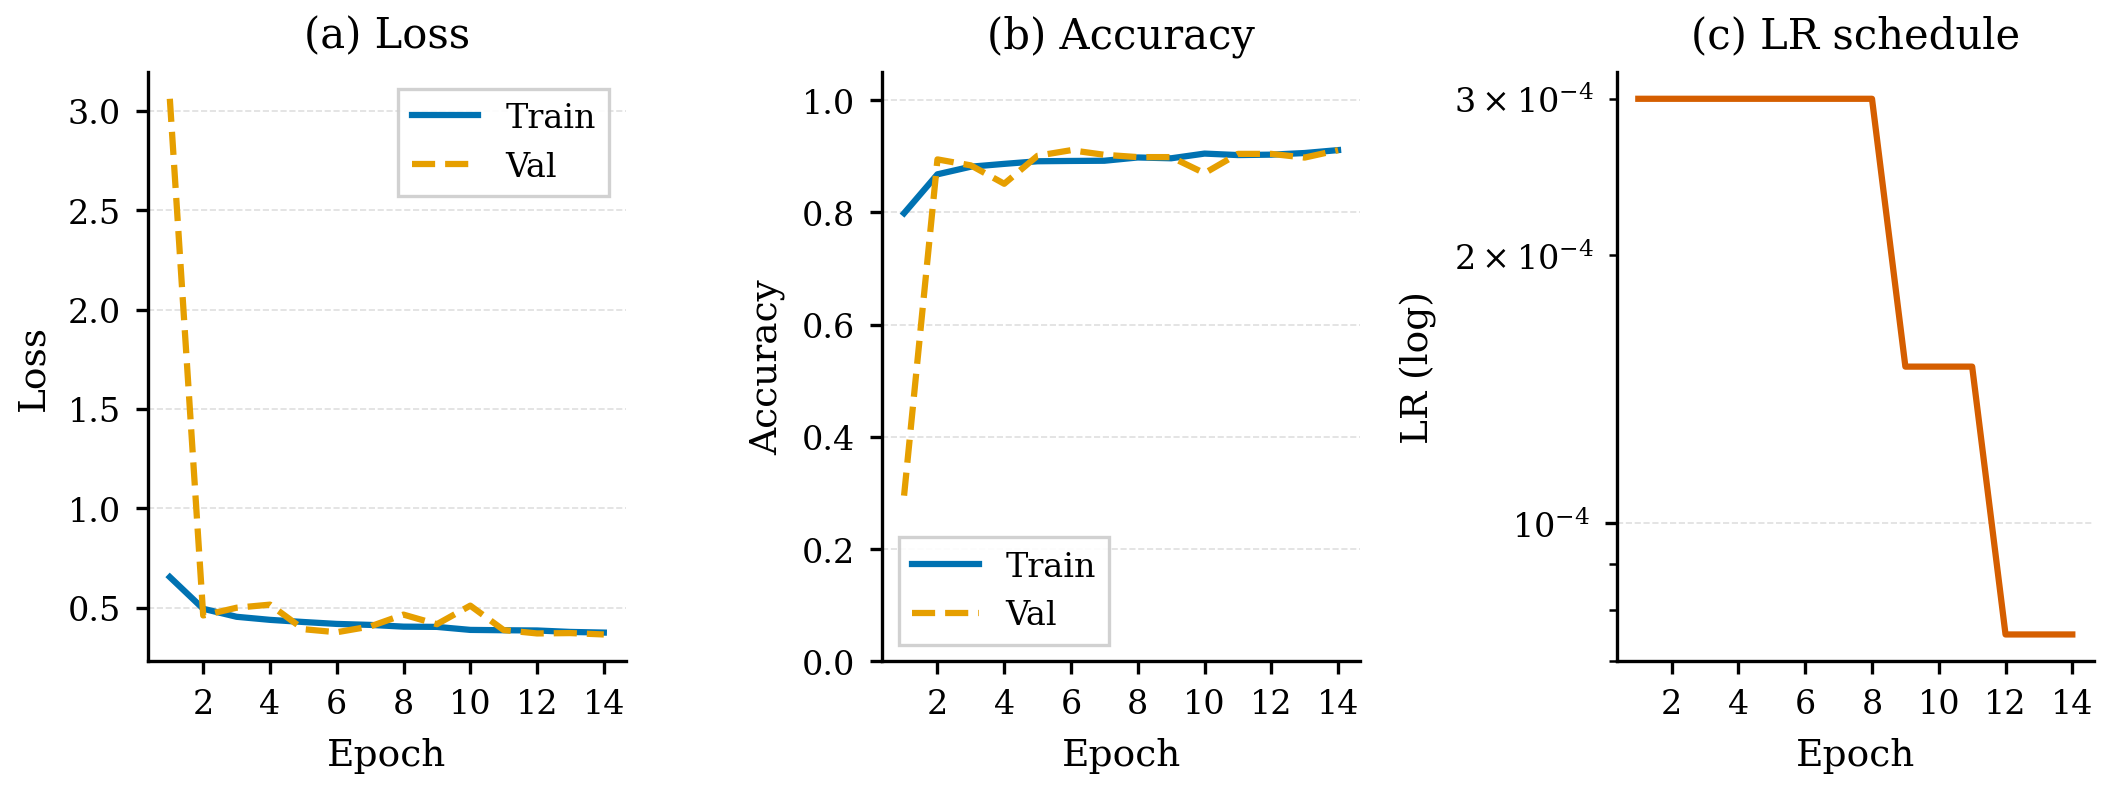

In [28]:
set_pub_style()
hist = history.history
hist_clean = {k: [float(x) for x in v] for k, v in hist.items()}
epochs_run = len(hist_clean['loss'])
ep = np.arange(1, epochs_run + 1)

meta = {
    'epochs_run'        : epochs_run,
    'batch_size'        : BATCH_SIZE,
    'steps_per_epoch'   : steps_per_epoch,
    'val_steps'         : val_steps,
    'classes'           : CLASSES,
    'img_size'          : IMG_SIZE,
    'spk_ch'            : SPK_CH,
    'reserve_per_class' : RESERVE_PER_CLASS,
    'train_val_split'   : TRAIN_VAL_SPLIT,
    'fast_mode'         : FAST_MODE,
    'seed'              : SEED,
    'train_time_sec'    : int(t1 - t0)
}
with open(HISTORY_JSON, 'w') as f:
    json.dump({'history': hist_clean, 'meta': meta}, f, indent=2)
print(f'History saved → {HISTORY_JSON}')

fig, axes = plt.subplots(1, 3, figsize=(7.2, 2.8))

axes[0].plot(ep, hist_clean['loss'],     color=PALETTE['train'], label='Train', lw=1.5)
axes[0].plot(ep, hist_clean['val_loss'], color=PALETTE['val'],   label='Val',
             lw=1.5, linestyle='--')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('(a) Loss'); axes[0].legend()
axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))

axes[1].plot(ep, hist_clean['accuracy'],     color=PALETTE['train'], label='Train', lw=1.5)
axes[1].plot(ep, hist_clean['val_accuracy'], color=PALETTE['val'],   label='Val',
             lw=1.5, linestyle='--')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('(b) Accuracy'); axes[1].set_ylim(0, 1.05); axes[1].legend()
axes[1].xaxis.set_major_locator(MaxNLocator(integer=True))

if 'lr' in hist_clean and hist_clean['lr']:
    axes[2].semilogy(ep, hist_clean['lr'], color=PALETTE['accent'], lw=1.5)
    axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('LR (log)')
    axes[2].set_title('(c) LR schedule')
    axes[2].xaxis.set_major_locator(MaxNLocator(integer=True))
else:
    axes[2].axis('off')
    axes[2].text(0.5, 0.5, 'LR not logged', ha='center', va='center',
                 transform=axes[2].transAxes, fontsize=8)

#fig.suptitle('CNN backbone training dynamics', fontsize=10)
fig.tight_layout()
save_fig(fig, 'fig3_training_curves')
display(IPImage(str(OUTPUT_DIR / 'fig3_training_curves.png')))

## Cell 16 — Validation Predictions + Classification Report

In [15]:
val_paths  = [p for p, _ in val_pairs]
val_labels = [class_to_idx[c] for _, c in val_pairs]

pred_logits = model.predict(build_val_plain(val_paths, val_labels), verbose=1)
y_pred      = np.argmax(pred_logits, axis=1)
y_true      = np.array(val_labels, dtype=np.int32)

num_classes = len(CLASSES)
cm = np.zeros((num_classes, num_classes), dtype=np.int64)
for t, p in zip(y_true, y_pred):
    cm[t, p] += 1

per_class_acc = [
    float(cm[i, i] / cm[i].sum()) if cm[i].sum() > 0 else 0.0
    for i in range(num_classes)
]
overall_acc = float((y_pred == y_true).mean())
top2_acc    = float(np.mean([
    y_true[i] in np.argsort(pred_logits[i])[-2:]
    for i in range(len(y_true))
]))

precision, recall, f1, support = precision_recall_fscore_support(
    y_true, y_pred, labels=list(range(num_classes)), zero_division=0
)
macro_f1    = float(f1.mean())
weighted_f1 = float(np.average(f1, weights=support))

print(f'\nFloat CNN — validation metrics')
print(f'  Overall accuracy : {overall_acc*100:.2f}%')
print(f'  Top-2 accuracy   : {top2_acc*100:.2f}%')
print(f'  Macro F1         : {macro_f1:.4f}')
print(f'  Weighted F1      : {weighted_f1:.4f}')
print(f'\nClassification report:')
print(classification_report(y_true, y_pred, target_names=CLASSES, digits=4))

with open(METRICS_JSON, 'w') as f:
    json.dump({
        'stage'             : 'float_cnn',
        'classes'           : CLASSES,
        'confusion_matrix'  : cm.tolist(),
        'per_class_accuracy': per_class_acc,
        'overall_accuracy'  : overall_acc,
        'top2_accuracy'     : top2_acc,
        'precision'         : precision.tolist(),
        'recall'            : recall.tolist(),
        'f1'                : f1.tolist(),
        'support'           : support.tolist(),
        'macro_f1'          : macro_f1,
        'weighted_f1'       : weighted_f1,
    }, f, indent=2)
print(f'\nMetrics saved → {METRICS_JSON}')

39/39 [==============================] - 1s 28ms/step

Float CNN — validation metrics
  Overall accuracy : 91.07%
  Top-2 accuracy   : 99.67%
  Macro F1         : 0.9205
  Weighted F1      : 0.9108

Classification report:
                  precision    recall  f1-score   support

   boxes_stacked     0.9957    0.9915    0.9936       235
     empty_aisle     0.9123    0.8667    0.8889       360
forklift_present     0.9149    0.9556    0.9348        90
   mixed_objects     0.8430    0.8788    0.8605       330
   unclear_scene     0.9223    0.9268    0.9246       205

        accuracy                         0.9107      1220
       macro avg     0.9177    0.9239    0.9205      1220
    weighted avg     0.9115    0.9107    0.9108      1220


Metrics saved → /kaggle/working/results/val_metrics.json


## Cell 17 — Confusion Matrix

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


  Saved: /kaggle/working/results/fig4_confusion_matrix.png


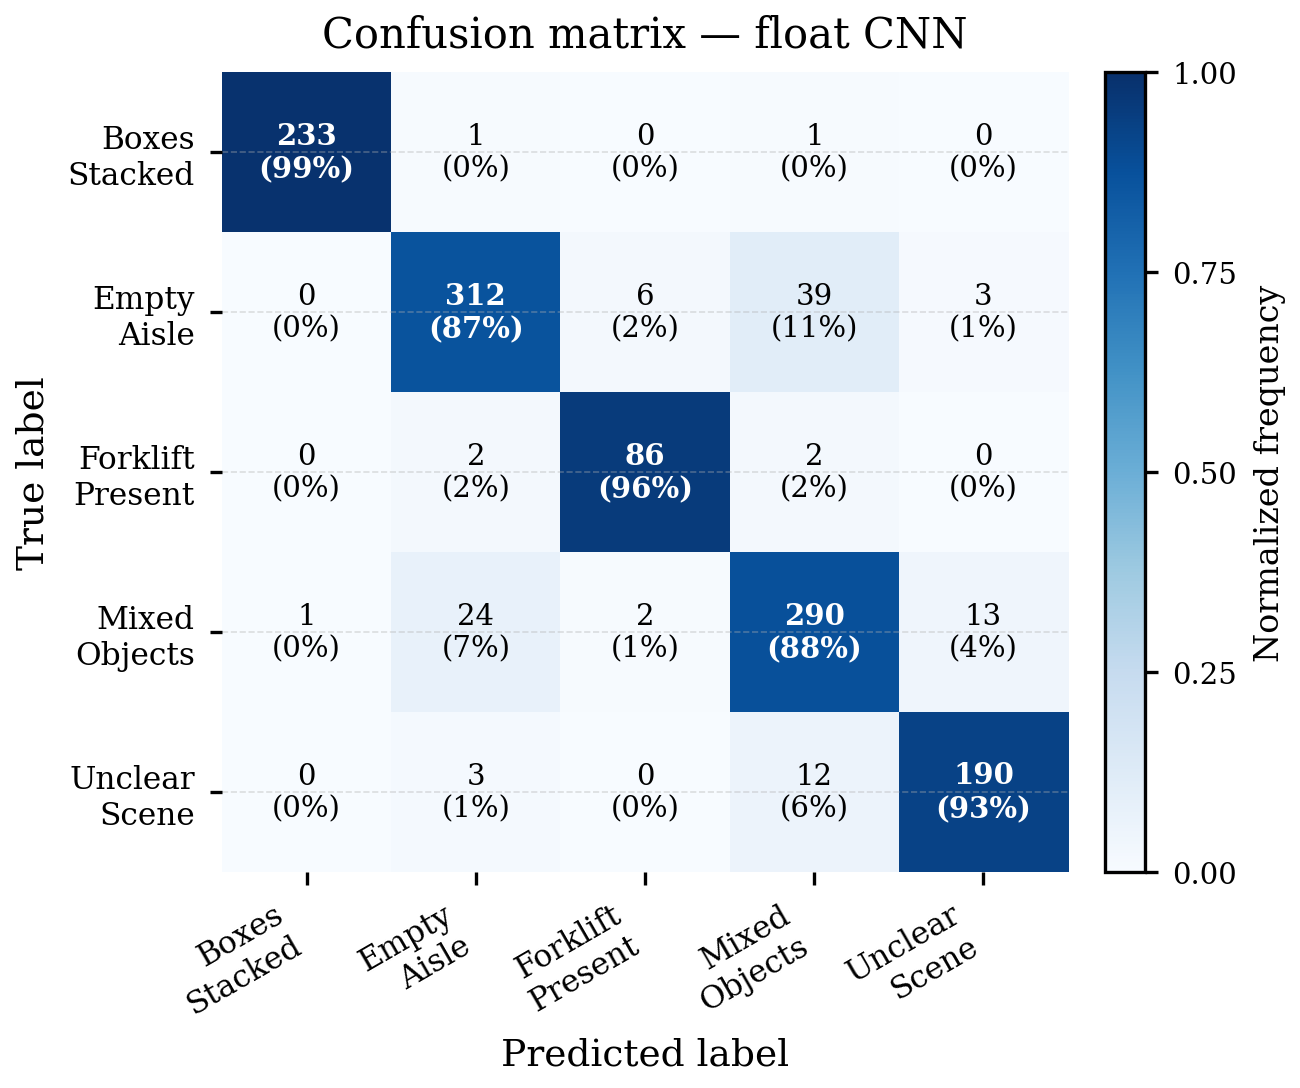

In [16]:
set_pub_style()
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(4.5, 3.8))
im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(num_classes)); ax.set_yticks(range(num_classes))
ax.set_xticklabels(CLASS_LABELS, fontsize=7.5, rotation=30, ha='right')
ax.set_yticklabels(CLASS_LABELS, fontsize=7.5)
ax.set_xlabel('Predicted label', fontsize=9)
ax.set_ylabel('True label', fontsize=9)
ax.set_title('Confusion matrix — float CNN', fontsize=10)
ax.spines[:].set_visible(False)
for i in range(num_classes):
    for j in range(num_classes):
        color = 'white' if cm_norm[i, j] > 0.55 else 'black'
        ax.text(j, i, f'{cm[i,j]}\n({cm_norm[i,j]*100:.0f}%)',
                ha='center', va='center', fontsize=7, color=color,
                fontweight='bold' if i == j else 'normal')
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=7)
cbar.set_label('Normalized frequency', fontsize=8)
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
fig.tight_layout()
save_fig(fig, 'fig4_confusion_matrix')
display(IPImage(str(OUTPUT_DIR / 'fig4_confusion_matrix.png')))

## Cell 18 — Per-Class Metrics: Precision / Recall / F1 / Accuracy

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


  Saved: /kaggle/working/results/fig5_perclass_metrics.png


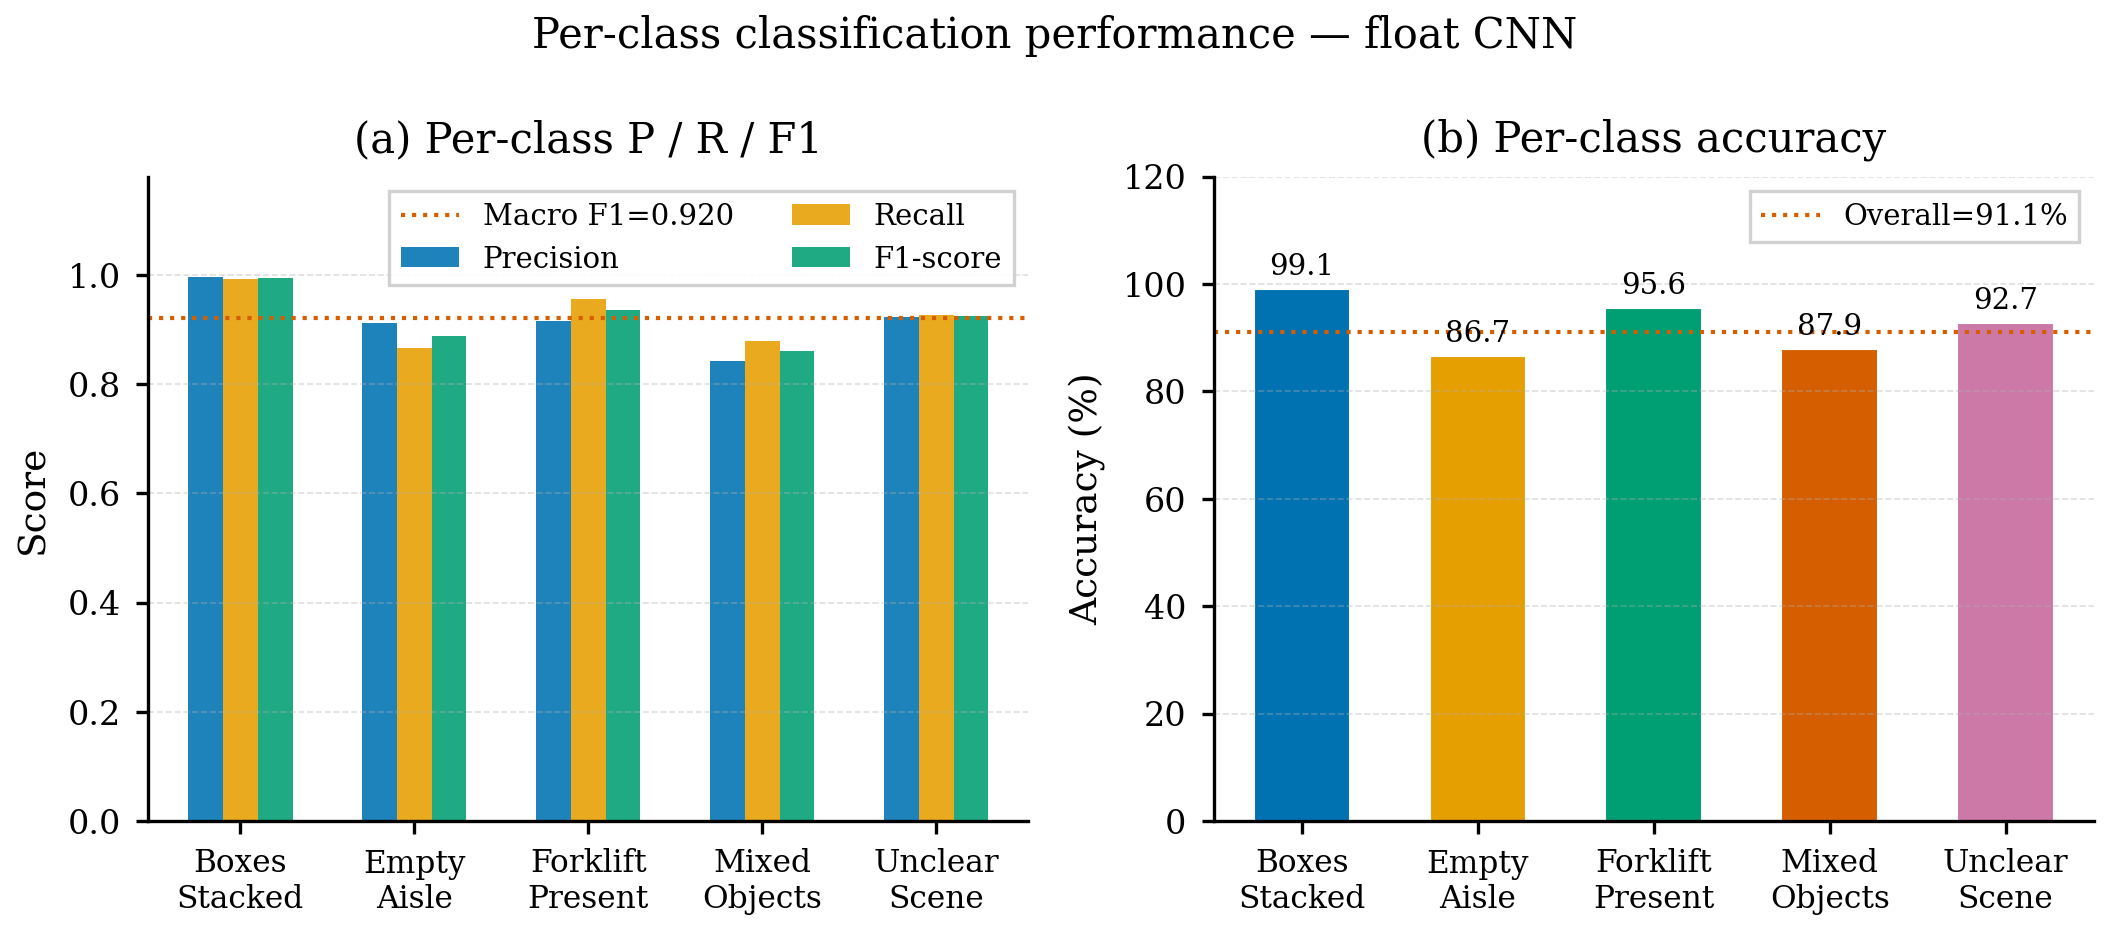

In [17]:
set_pub_style()
x = np.arange(num_classes)
w = 0.20

fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.2))

axes[0].bar(x - w, precision, w, label='Precision', color=PALETTE['train'],  alpha=0.88)
axes[0].bar(x,     recall,    w, label='Recall',    color=PALETTE['val'],    alpha=0.88)
axes[0].bar(x + w, f1,        w, label='F1-score',  color=PALETTE['snn'],    alpha=0.88)
axes[0].set_xticks(x); axes[0].set_xticklabels(CLASS_LABELS, fontsize=7.5)
axes[0].set_ylim(0, 1.18); axes[0].set_ylabel('Score')
axes[0].set_title('(a) Per-class P / R / F1')
axes[0].axhline(y=macro_f1, color=PALETTE['accent'], lw=1.0,
                linestyle=':', label=f'Macro F1={macro_f1:.3f}')
axes[0].legend(fontsize=7, ncol=2)

bars = axes[1].bar(x, [a*100 for a in per_class_acc], color=CLASS_COLORS,
                   edgecolor='white', linewidth=0.5, width=0.55)
axes[1].axhline(y=overall_acc*100, color=PALETTE['accent'], lw=1.0,
                linestyle=':', label=f'Overall={overall_acc*100:.1f}%')
axes[1].set_xticks(x); axes[1].set_xticklabels(CLASS_LABELS, fontsize=7.5)
axes[1].set_ylim(0, 120); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('(b) Per-class accuracy'); axes[1].legend(fontsize=7)
for bar, acc in zip(bars, per_class_acc):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                 f'{acc*100:.1f}', ha='center', va='bottom', fontsize=7)

fig.suptitle('Per-class classification performance — float CNN', fontsize=10)
fig.tight_layout()
save_fig(fig, 'fig5_perclass_metrics')
display(IPImage(str(OUTPUT_DIR / 'fig5_perclass_metrics.png')))

## Cell 19 — Quantize 8/4/4 + Force 1-bit Spike (cnn2snn API)

> **This is the critical cell that determines FBZ compatibility.**
>
> We use `cnn2snn.quantize()` + `cnn2snn.quantize_layer()` — NOT QuantizeML.
> This is the only API that reliably forces `spike_relu` to 1-bit,
> producing `tmp_logits input_bits=1` in the FBZ.
>
> The two `quantize_layer()` calls are **mandatory**:
> - `quantize_layer(model, "spike_relu", 1)` → forces 1-bit binary spike output
> - `quantize_layer(model, "tmp_logits", 2)` → 2-bit logits (matches working pipeline)

In [18]:
# ================================================================
# Cell 19 — Quantize with cnn2snn API (working pipeline)
#
# This exactly matches the local pipeline that produced the
# confirmed-working warehouse_edge_backbone_full.fbz.
#
# Step 1: quantize() with 8/4/4 scheme
#   input_weight_quantization=8 → absorbs Rescaling(1/255) → conv1 input_bits=8
#   weight_quantization=4       → all conv/dense weights 4-bit
#   activ_quantization=4        → all activations 4-bit
#
# Step 2: quantize_layer("spike_relu", 1) → FORCES 1-bit on spike output
#   Without this, spike_relu stays 4-bit → AkidaUnsupervised FAILS
#
# Step 3: quantize_layer("tmp_logits", 2) → 2-bit logits
# ================================================================
print('Loading best checkpoint for quantization...')
best_model = tf_keras.models.load_model(BEST_H5)

print('Step 1: quantize 8/4/4 with cnn2snn.quantize()...')
qmodel = quantize(
    best_model,
    input_weight_quantization=8,
    weight_quantization=4,
    activ_quantization=4
)

print('Step 2: force 1-bit on spike_relu...')
qmodel = quantize_layer(qmodel, 'spike_relu', 1)

print('Step 3: force 2-bit on tmp_logits...')
qmodel = quantize_layer(qmodel, 'tmp_logits', 2)

print('\nQuantization complete.')
qmodel.summary()

qmodel.save(QUANT_H5)
print(f'Quantized model saved → {QUANT_H5}')

Loading best checkpoint for quantization...
Step 1: quantize 8/4/4 with cnn2snn.quantize()...
Step 2: force 1-bit on spike_relu...
Step 3: force 2-bit on tmp_logits...

Quantization complete.
Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescale (Rescaling)         (None, 160, 160, 3)       0         
                                                                 
 conv1 (QuantizedConv2D)     (None, 80, 80, 32)        896       
                                                                 
 relu1 (QuantizedReLU)       (None, 80, 80, 32)        0         
                                                                 
 conv2 (QuantizedConv2D)     (None, 40, 40, 64)        18496     
                                                                 
 relu2 (QuantizedReLU)       (None, 40, 40, 64)        0         
                                                            

## Cell 20 — Quantization Analysis

39/39 [==============================] - 1s 29ms/step
Float  accuracy: 91.07%  size: 19.61 MB
Quant  accuracy: 90.41%   size: 6.53 MB
Accuracy drop  : 0.66 pp
Compression    : 3.00x (66.7% reduction)


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


  Saved: /kaggle/working/results/fig6_quantization_analysis.png


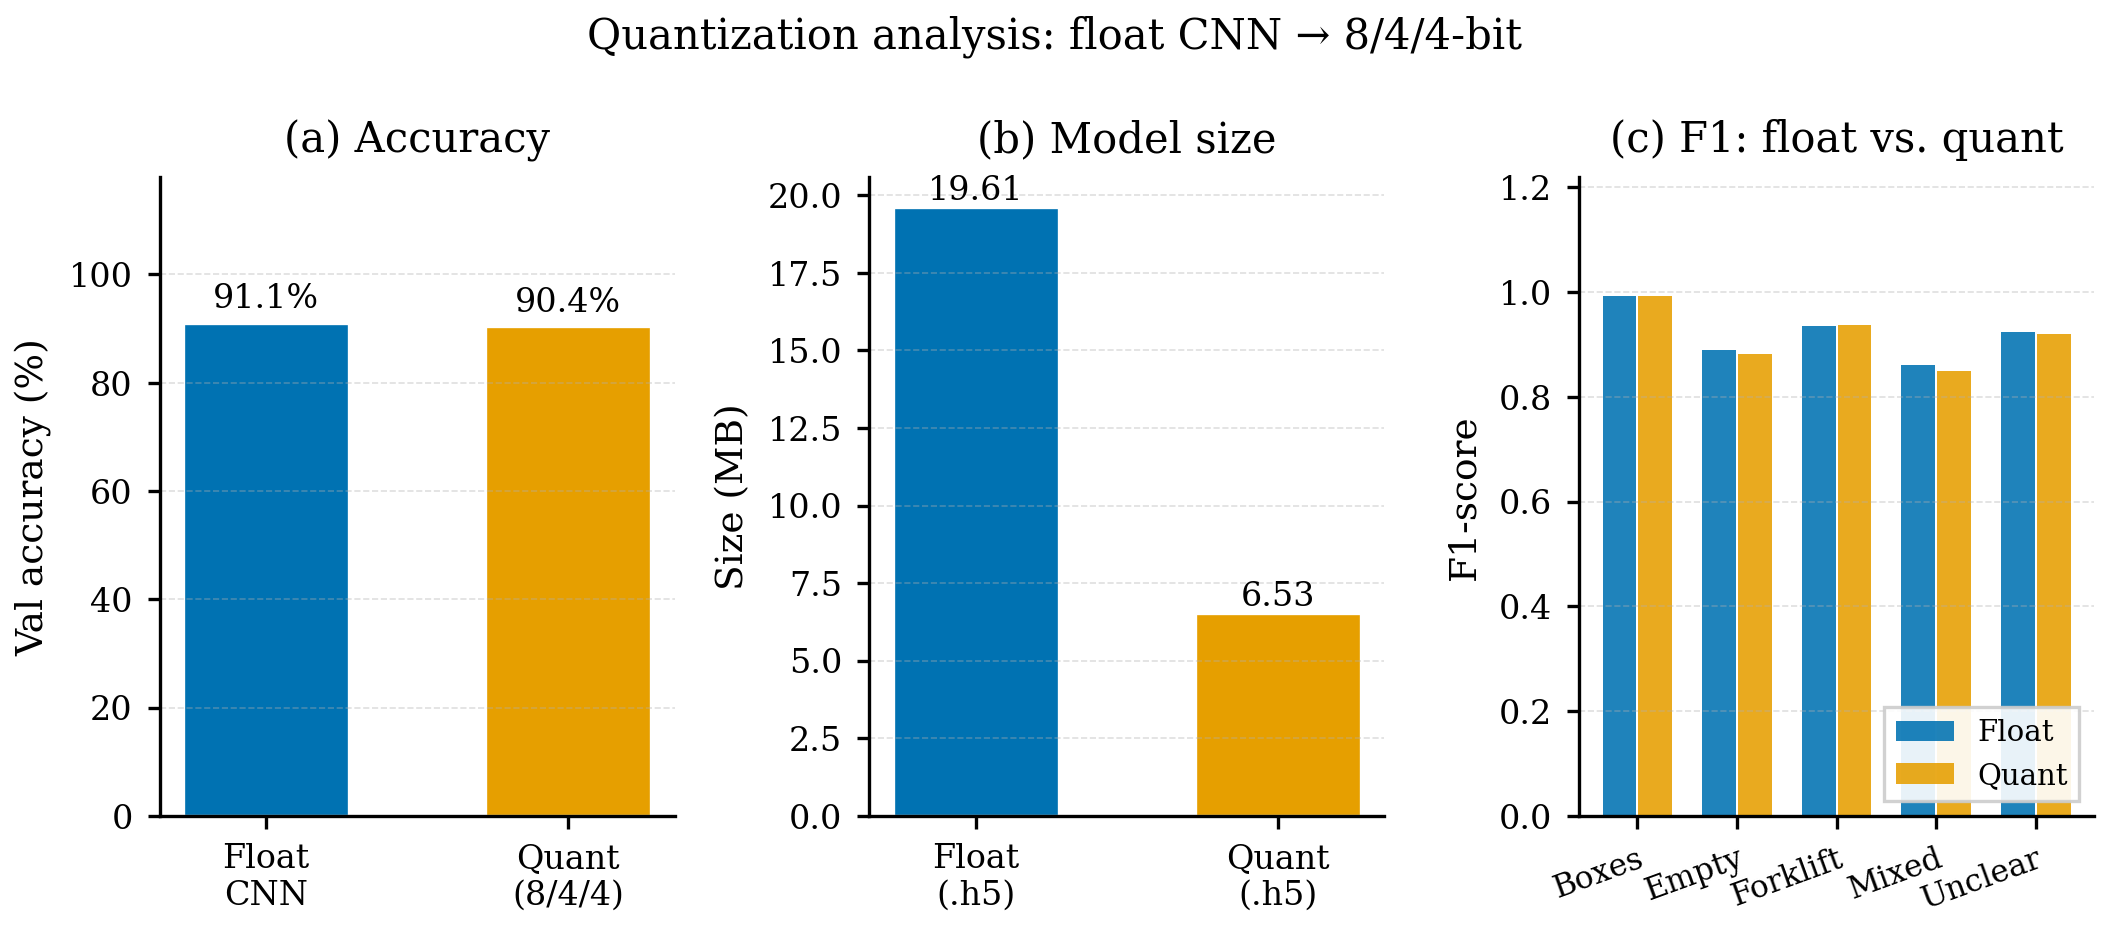

In [19]:
set_pub_style()

qmodel.compile(
    optimizer=optimizers.Adam(3e-4),
    loss=losses.CategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)
val_ds_eval = build_tfds(val_pairs, class_to_idx, BATCH_SIZE, train=False)
q_loss, q_acc = qmodel.evaluate(val_ds_eval, steps=val_steps, verbose=1)

q_logits = qmodel.predict(build_val_plain(val_paths, val_labels), verbose=1)
q_pred   = np.argmax(q_logits, axis=1)
q_cm     = np.zeros((num_classes, num_classes), dtype=np.int64)
for t, p in zip(y_true, q_pred): q_cm[t, p] += 1
q_per_class_acc = [
    float(q_cm[i, i] / q_cm[i].sum()) if q_cm[i].sum() > 0 else 0.0
    for i in range(num_classes)
]
q_prec, q_rec, q_f1, _ = precision_recall_fscore_support(
    y_true, q_pred, labels=list(range(num_classes)), zero_division=0
)

float_size_mb = os.path.getsize(BEST_H5)  / (1024**2)
q_size_mb     = os.path.getsize(QUANT_H5) / (1024**2)
compression   = float_size_mb / q_size_mb if q_size_mb > 0 else 1.0

print(f'Float  accuracy: {overall_acc*100:.2f}%  size: {float_size_mb:.2f} MB')
print(f'Quant  accuracy: {q_acc*100:.2f}%   size: {q_size_mb:.2f} MB')
print(f'Accuracy drop  : {(overall_acc - q_acc)*100:.2f} pp')
print(f'Compression    : {compression:.2f}x ({(1 - 1/compression)*100:.1f}% reduction)')

CLASS_SHORT_Q = ['Boxes', 'Empty', 'Forklift', 'Mixed', 'Unclear']

fig, axes = plt.subplots(1, 3, figsize=(7.2, 3.2))

axes[0].bar([0, 1], [overall_acc*100, q_acc*100],
            color=[PALETTE['float'], PALETTE['quant']], edgecolor='white', width=0.55)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Float\nCNN', 'Quant\n(8/4/4)'], fontsize=8)
axes[0].set_ylabel('Val accuracy (%)'); axes[0].set_ylim(0, 118)
axes[0].set_title('(a) Accuracy')
for i, a in enumerate([overall_acc*100, q_acc*100]):
    axes[0].text(i, a + 1.5, f'{a:.1f}%', ha='center', va='bottom', fontsize=8)

axes[1].bar([0, 1], [float_size_mb, q_size_mb],
            color=[PALETTE['float'], PALETTE['quant']], edgecolor='white', width=0.55)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Float\n(.h5)', 'Quant\n(.h5)'], fontsize=8)
axes[1].set_ylabel('Size (MB)'); axes[1].set_title('(b) Model size')
for i, s in enumerate([float_size_mb, q_size_mb]):
    axes[1].text(i, s + 0.02, f'{s:.2f}', ha='center', va='bottom', fontsize=8)

xq = np.arange(num_classes)
axes[2].bar(xq - 0.18, f1,   0.34, label='Float', color=PALETTE['float'], alpha=0.88)
axes[2].bar(xq + 0.18, q_f1, 0.34, label='Quant', color=PALETTE['quant'], alpha=0.88)
axes[2].set_xticks(xq)
axes[2].set_xticklabels(CLASS_SHORT_Q, fontsize=7.5, rotation=20,
                        ha='right', rotation_mode='anchor')
axes[2].set_ylim(0, 1.22); axes[2].set_ylabel('F1-score')
axes[2].set_title('(c) F1: float vs. quant')
axes[2].legend(fontsize=7, loc='lower right')

fig.suptitle('Quantization analysis: float CNN → 8/4/4-bit', fontsize=10)
fig.tight_layout()
save_fig(fig, 'fig6_quantization_analysis')
display(IPImage(str(OUTPUT_DIR / 'fig6_quantization_analysis.png')))

## Cell 21 — Convert to Akida v1 and Save .fbz

In [20]:
# ================================================================
# Cell 21 — Convert to Akida v1
#
# Uses cnn2snn.convert() — same as the working local pipeline.
# No input_scaling needed here because Rescaling(1/255) was in
# the model and was absorbed by cnn2snn.quantize() into the
# 8-bit input quantization. The FBZ receives raw uint8 at inference.
# ================================================================
print('Converting to Akida v1...')
with set_akida_version(AkidaVersion.v1):
    ak_model = convert(qmodel)

print('\nAkida model summary:')
print(ak_model.summary())

ak_model.save(FBZ_OUT)
fbz_size_kb = os.path.getsize(FBZ_OUT) / 1024
print(f'\nFBZ saved → {FBZ_OUT}  ({fbz_size_kb:.1f} KB)')

devs = devices()
if devs:
    ak_model.map(devs[0])
    print('Mapped to Akida device:', devs[0])
else:
    print('No Akida hardware on Kaggle (expected). Deploy .fbz to edge device.')

Converting to Akida v1...

Akida model summary:
                 Model Summary                  
________________________________________________
Input shape    Output shape  Sequences  Layers
[160, 160, 3]  [1, 1, 5]     1          6     
________________________________________________

_______________________________________________________
Layer (type)          Output shape   Kernel shape    

============ SW/conv1-tmp_logits (Software) ===========

conv1 (InputConv.)    [80, 80, 32]   (3, 3, 3, 32)   
_______________________________________________________
conv2 (Conv.)         [40, 40, 64]   (3, 3, 32, 64)  
_______________________________________________________
sepconv1 (Sep.Conv.)  [20, 20, 128]  (3, 3, 64, 1)   
_______________________________________________________
                                     (1, 1, 64, 128) 
_______________________________________________________
sepconv2 (Sep.Conv.)  [5, 5, 256]    (3, 3, 128, 1)  
________________________________________________

## Cell 21b — FBZ Verification (MANDATORY before downloading)
> This cell verifies the FBZ will work on the edge nodes.
> **Do not download or deploy the FBZ if this cell fails.**
>
> Expected output:
> ```
> [4] spike_conv7   input_bits=4  output_signed=False
> [5] tmp_logits    input_bits=1  output_signed=True
> compile() → SUCCESS
> ```

In [21]:
# ================================================================
# Cell 21b — FBZ compatibility check
# Reproduces exactly what the edge nodes do during FL training.
# ================================================================
import akida as _ak
from akida import FullyConnected as _FC, AkidaUnsupervised as _AU

print('=' * 60)
print('FBZ compatibility verification')
print('=' * 60)

_m = _ak.Model(FBZ_OUT)
print('\nLayer structure:')
for i, layer in enumerate(_m.layers):
    od    = getattr(layer, 'output_dims',  'N/A')
    ibits = getattr(layer, 'input_bits',   'N/A')
    osign = getattr(layer, 'output_signed','N/A')
    print(f'  [{i}] {layer.name:<22} out={str(od):<18} '
          f'input_bits={ibits}  output_signed={osign}')

_prev = _m.layers[-2]
_od   = getattr(_prev, 'output_dims', None)
print(f'\nPre-logits layer   : {_prev.name}')
print(f'output_dims        : {_od}')
print(f'output_signed      : {getattr(_prev, "output_signed", "N/A")}')

_last_before_pop = _m.layers[-1]
_ibits_logits = getattr(_last_before_pop, 'input_bits', 'N/A')
print(f'\ntmp_logits input_bits : {_ibits_logits}')

# The critical check: tmp_logits must receive 1-bit (binary) inputs
assert _ibits_logits == 1, (
    f'FAIL: tmp_logits input_bits={_ibits_logits}, expected 1.\n'
    f'The quantize_layer("spike_relu", 1) step did not work correctly.\n'
    f'Do NOT deploy this FBZ.'
)
print('tmp_logits input_bits=1 confirmed (binary spikes)')

# fan_in check
if _od:
    _h, _w, _c = _od
    _fan_in = int(_h * _w * _c)
    print(f'fan_in             : {_h}x{_w}x{_c} = {_fan_in}')
    assert _fan_in == SPK_CH, (
        f'fan_in={_fan_in} but expected SPK_CH={SPK_CH}.\n'
        f'The spike_conv7 did not collapse to 1x1.'
    )
    print(f'fan_in={_fan_in} matches SPK_CH={SPK_CH} confirmed')

# Pop and compile test
_m.pop_layer()
_nw = max(32, min(_fan_in, int(round(0.5 * _fan_in))))
_m.add(_FC(name='akida_edge_layer', units=5*100, activation=False))

try:
    _m.compile(optimizer=_AU(num_weights=_nw, num_classes=5, learning_competition=0.1))
    _vnames = _m.layers[-1].get_variable_names()
    print(f'\ncompile() → SUCCESS')
    print(f'Variable names: {_vnames}')
    print(f'\nFBZ is COMPATIBLE with AkidaUnsupervised FL training.')
    print('Safe to download and deploy to sai5, sai7, sai8.')
except Exception as e:
    print(f'\ncompile() → FAILED: {e}')
    print('DO NOT DEPLOY this FBZ.')
    raise

del _m
print('=' * 60)

FBZ compatibility verification

Layer structure:
  [0] conv1                  out=[80, 80, 32]       input_bits=8  output_signed=False
  [1] conv2                  out=[40, 40, 64]       input_bits=4  output_signed=False
  [2] sepconv1               out=[20, 20, 128]      input_bits=4  output_signed=False
  [3] sepconv2               out=[5, 5, 256]        input_bits=4  output_signed=False
  [4] spike_conv7            out=[1, 1, 256]        input_bits=4  output_signed=False
  [5] tmp_logits             out=[1, 1, 5]          input_bits=1  output_signed=True

Pre-logits layer   : spike_conv7
output_dims        : [1, 1, 256]
output_signed      : False

tmp_logits input_bits : 1
tmp_logits input_bits=1 confirmed (binary spikes)
fan_in             : 1x1x256 = 256
fan_in=256 matches SPK_CH=256 confirmed

compile() → SUCCESS
Variable names: ['act_step', 'threshold', 'threshold_learning', 'thswap', 'weights']

FBZ is COMPATIBLE with AkidaUnsupervised FL training.
Safe to download and deploy t

## Cell 22 — Akida SW Inference Smoke Test

In [22]:
# ================================================================
# FBZ receives raw uint8 [0-255].
# Rescaling was absorbed into 8-bit input quantization by cnn2snn.
# ================================================================
SMOKE_N = min(200, len(val_paths))
smoke_paths  = val_paths[:SMOKE_N]
smoke_labels = val_labels[:SMOKE_N]

smoke_imgs = []
for p in smoke_paths:
    raw = tf.io.read_file(p)
    img = tf.io.decode_image(raw, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE, method='bilinear')
    img = tf.cast(img, tf.uint8).numpy()   # uint8 [0-255]
    smoke_imgs.append(img)
smoke_imgs = np.stack(smoke_imgs)

print(f'Input shape: {smoke_imgs.shape} | dtype: {smoke_imgs.dtype}')

ak_preds        = ak_model.predict(smoke_imgs)
ak_preds_flat   = ak_preds.reshape(len(smoke_imgs), -1)
ak_pred_classes = np.argmax(ak_preds_flat, axis=1)
ak_acc          = float((ak_pred_classes == np.array(smoke_labels)).mean())

print(f'\nAkida SW smoke test ({SMOKE_N} samples): {ak_acc*100:.1f}% accuracy')
print(f'Float CNN val accuracy                : {overall_acc*100:.1f}%')
print(f'Accuracy drop Float → Akida SNN       : {(overall_acc - ak_acc)*100:.2f} pp')

Input shape: (200, 160, 160, 3) | dtype: uint8

Akida SW smoke test (200 samples): 92.0% accuracy
Float CNN val accuracy                : 91.1%
Accuracy drop Float → Akida SNN       : -0.93 pp


## Cell 23 — 3-Stage Pipeline Summary


Metric                              Float CNN     Quant Akida SNN
Val accuracy (%)                        91.07     90.41     92.00
Model size (MB)                         19.61      6.53      1.91
Compression vs float                     1.0x      3.0x     10.3x


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


  Saved: /kaggle/working/results/fig7_pipeline_summary.png


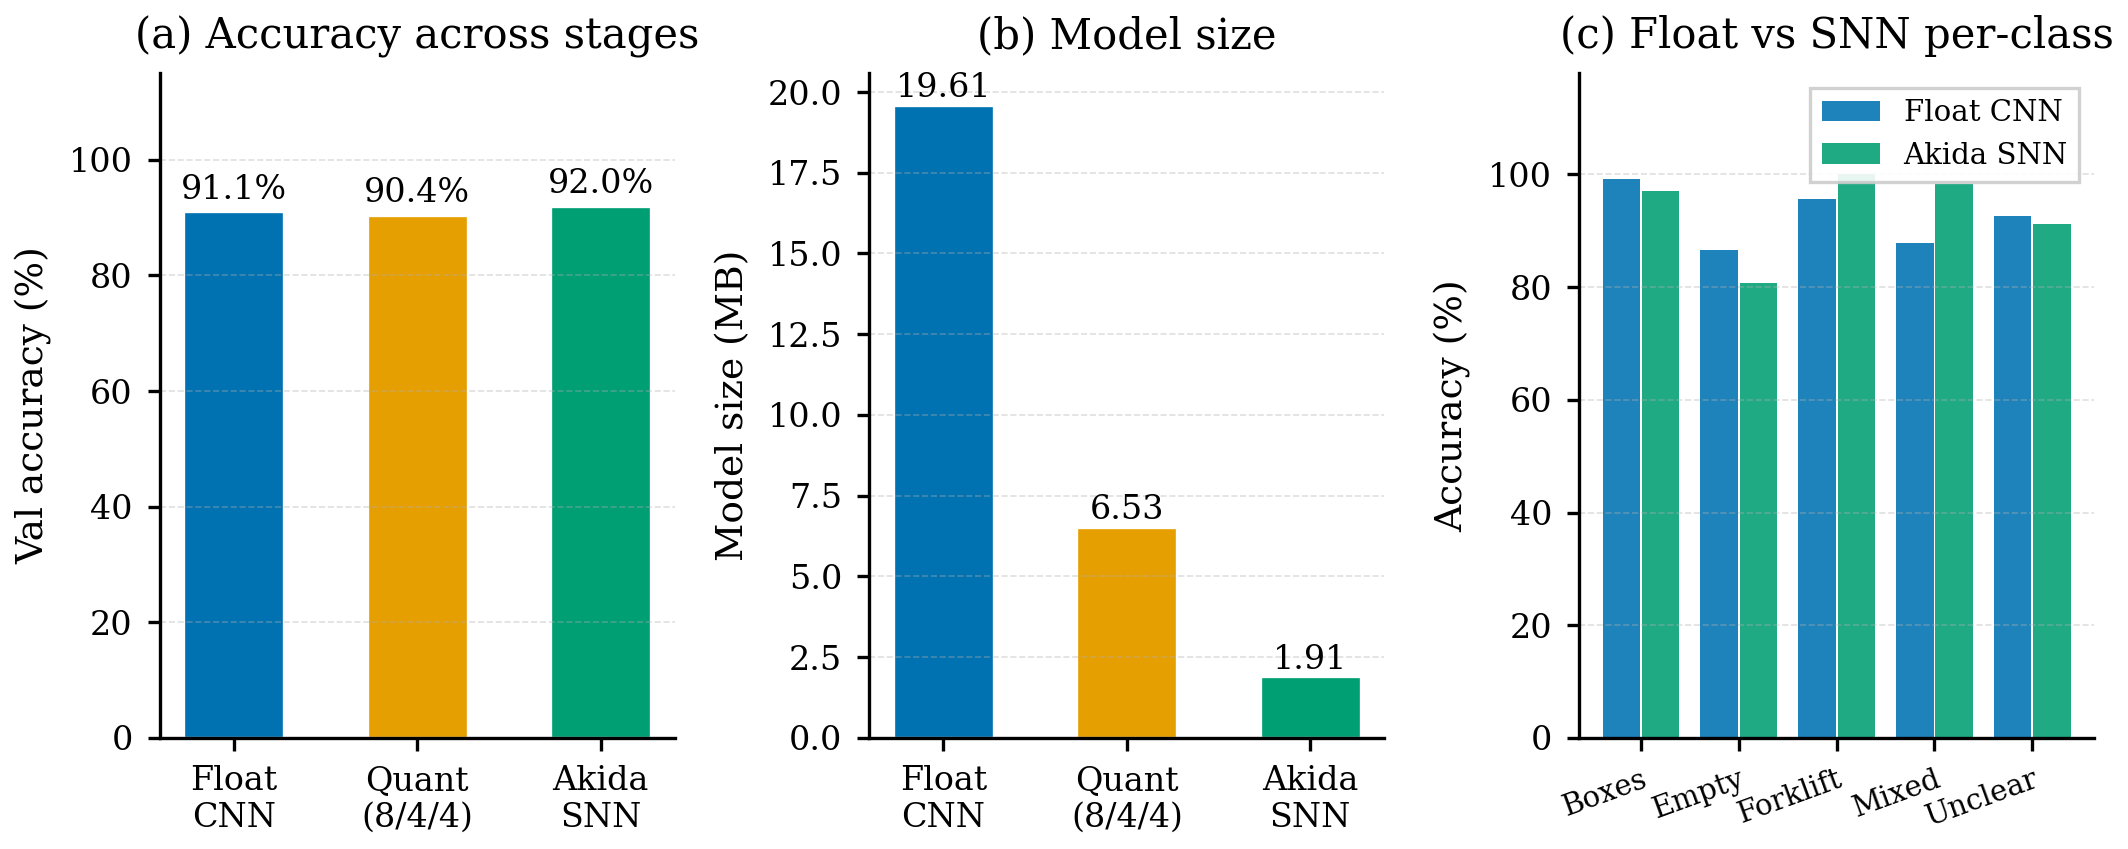

In [29]:
set_pub_style()

fbz_size_kb   = os.path.getsize(FBZ_OUT) / 1024
float_size_mb = os.path.getsize(BEST_H5)  / (1024**2)
q_size_mb     = os.path.getsize(QUANT_H5) / (1024**2)
fbz_size_mb   = fbz_size_kb / 1024

compression_q_float   = float_size_mb / q_size_mb   if q_size_mb   > 0 else 1.0
compression_fbz_float = float_size_mb / fbz_size_mb if fbz_size_mb > 0 else 1.0

print('\n' + '=' * 64)
print(f'{"Metric":<35} {"Float CNN":>9} {"Quant":>9} {"Akida SNN":>9}')
print('=' * 64)
print(f'{"Val accuracy (%)": <35} {overall_acc*100:>9.2f} {q_acc*100:>9.2f} {ak_acc*100:>9.2f}')
print(f'{"Model size (MB)":<35} {float_size_mb:>9.2f} {q_size_mb:>9.2f} {fbz_size_mb:>9.2f}')
print(f'{"Compression vs float":<35} {"1.0x":>9} {compression_q_float:>8.1f}x {compression_fbz_float:>8.1f}x')
print('=' * 64)

smoke_true = np.array(smoke_labels)
snn_cm = np.zeros((num_classes, num_classes), dtype=np.int64)
for t, p in zip(smoke_true, ak_pred_classes):
    snn_cm[t, p] += 1
snn_per_class_acc = [
    float(snn_cm[i, i] / snn_cm[i].sum()) if snn_cm[i].sum() > 0 else 0.0
    for i in range(num_classes)
]

fig, axes = plt.subplots(1, 3, figsize=(7.2, 3.0))
stages       = ['Float\nCNN', 'Quant\n(8/4/4)', 'Akida\nSNN']
stage_accs   = [overall_acc*100, q_acc*100, ak_acc*100]
stage_sizes  = [float_size_mb, q_size_mb, fbz_size_mb]
stage_colors = [PALETTE['float'], PALETTE['quant'], PALETTE['snn']]

bars0 = axes[0].bar([0, 1, 2], stage_accs, color=stage_colors, edgecolor='white', width=0.55)
axes[0].set_xticks([0, 1, 2]); axes[0].set_xticklabels(stages, fontsize=8)
axes[0].set_ylim(0, 115); axes[0].set_ylabel('Val accuracy (%)')
axes[0].set_title('(a) Accuracy across stages')
for bar, a in zip(bars0, stage_accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, a + 1, f'{a:.1f}%',
                 ha='center', va='bottom', fontsize=8)

bars1 = axes[1].bar([0, 1, 2], stage_sizes, color=stage_colors, edgecolor='white', width=0.55)
axes[1].set_xticks([0, 1, 2]); axes[1].set_xticklabels(stages, fontsize=8)
axes[1].set_ylabel('Model size (MB)'); axes[1].set_title('(b) Model size')
for bar, s in zip(bars1, stage_sizes):
    axes[1].text(bar.get_x() + bar.get_width()/2, s + 0.02, f'{s:.2f}',
                 ha='center', va='bottom', fontsize=8)

x = np.arange(num_classes)
axes[2].bar(x - 0.2, [a*100 for a in per_class_acc], 0.38,
            label='Float CNN', color=PALETTE['float'], alpha=0.88)
axes[2].bar(x + 0.2, [a*100 for a in snn_per_class_acc], 0.38,
            label='Akida SNN', color=PALETTE['snn'], alpha=0.88)
axes[2].set_xticks(x)
axes[2].set_xticklabels(['Boxes', 'Empty', 'Forklift', 'Mixed', 'Unclear'],
                        fontsize=7, rotation=20, ha='right', rotation_mode='anchor')
axes[2].set_ylim(0, 118); axes[2].set_ylabel('Accuracy (%)')
axes[2].set_title('(c) Float vs SNN per-class')
axes[2].legend(fontsize=7)

#fig.suptitle('CNN → quantization → Akida SNN: pipeline summary', fontsize=10)
fig.tight_layout()
save_fig(fig, 'fig7_pipeline_summary')
display(IPImage(str(OUTPUT_DIR / 'fig7_pipeline_summary.png')))

## Cell 24 — Save All Metrics (3-stage JSON)

In [30]:
all_metrics = {
    'pipeline': 'CNN → cnn2snn quantize (8/4/4) + quantize_layer (1-bit spike) → Akida v1 SNN',
    'quantization_api': 'cnn2snn.quantize + cnn2snn.quantize_layer',
    'dataset': {
        'name'              : 'Warehouse',
        'classes'           : CLASSES,
        'total_images'      : sum(len(v) for v in files_by_class.values()),
        'reserve_per_class' : RESERVE_PER_CLASS,
        'train_pairs'       : len(train_pairs),
        'val_pairs'         : len(val_pairs),
        'img_size'          : IMG_SIZE,
        'fast_mode'         : FAST_MODE,
        'seed'              : SEED,
    },
    'training': {
        'epochs_run'        : epochs_run,
        'train_time_sec'    : int(t1 - t0),
        'batch_size'        : BATCH_SIZE,
        'best_val_accuracy' : float(max(hist_clean['val_accuracy'])),
        'final_train_loss'  : float(hist_clean['loss'][-1]),
    },
    'float_cnn': {
        'val_accuracy'      : overall_acc,
        'top2_accuracy'     : top2_acc,
        'macro_f1'          : macro_f1,
        'weighted_f1'       : weighted_f1,
        'model_size_mb'     : float_size_mb,
        'per_class_accuracy': per_class_acc,
        'precision'         : precision.tolist(),
        'recall'            : recall.tolist(),
        'f1'                : f1.tolist(),
        'support'           : support.tolist(),
        'confusion_matrix'  : cm.tolist(),
    },
    'quantized_8_4_4': {
        'val_accuracy'        : q_acc,
        'accuracy_drop_pp'    : (overall_acc - q_acc) * 100,
        'model_size_mb'       : q_size_mb,
        'compression_vs_float': compression_q_float,
        'per_class_accuracy'  : q_per_class_acc,
        'f1'                  : q_f1.tolist(),
        'confusion_matrix'    : q_cm.tolist(),
    },
    'akida_snn': {
        'val_accuracy_smoke'  : ak_acc,
        'smoke_n'             : SMOKE_N,
        'accuracy_drop_pp'    : (overall_acc - ak_acc) * 100,
        'fbz_size_mb'         : fbz_size_mb,
        'compression_vs_float': compression_fbz_float,
        'per_class_accuracy'  : snn_per_class_acc,
        'akida_version'       : 'v1',
        'quantization_scheme' : '8/4/4 + forced 1-bit spike',
        'spike_layer_bits'    : 1,
        'fbz_verified'        : True,
    },
}

all_metrics_path = str(OUTPUT_DIR / 'all_metrics_3stage.json')
with open(all_metrics_path, 'w') as f:
    json.dump(all_metrics, f, indent=2)
print(f'All metrics saved → {all_metrics_path}')

print('\n' + '=' * 64)
print('FINAL PIPELINE RESULTS SUMMARY')
print('=' * 64)
print(f'  Float CNN val accuracy      : {overall_acc*100:.2f}%')
print(f'  Quantized (8/4/4) accuracy  : {q_acc*100:.2f}%  (D = {(overall_acc-q_acc)*100:.2f} pp)')
print(f'  Akida SNN accuracy (SW)     : {ak_acc*100:.2f}%  (D = {(overall_acc-ak_acc)*100:.2f} pp)')
print(f'  Float model size            : {float_size_mb:.2f} MB')
print(f'  Quantized size              : {q_size_mb:.2f} MB  ({compression_q_float:.1f}x compression)')
print(f'  Akida .fbz size             : {fbz_size_mb:.2f} MB  ({compression_fbz_float:.1f}x compression)')
print(f'  Macro F1 (float)            : {macro_f1:.4f}')
print(f'  Weighted F1 (float)         : {weighted_f1:.4f}')
print('=' * 64)

All metrics saved → /kaggle/working/results/all_metrics_3stage.json

FINAL PIPELINE RESULTS SUMMARY
  Float CNN val accuracy      : 91.07%
  Quantized (8/4/4) accuracy  : 90.41%  (D = 0.66 pp)
  Akida SNN accuracy (SW)     : 92.00%  (D = -0.93 pp)
  Float model size            : 19.61 MB
  Quantized size              : 6.53 MB  (3.0x compression)
  Akida .fbz size             : 1.91 MB  (10.3x compression)
  Macro F1 (float)            : 0.9205
  Weighted F1 (float)         : 0.9108


## Cell 25 — Output Listing + Deployment Instructions

In [31]:
print('=== Files to download ===')
for f in [FBZ_OUT, RESERVED_PATHS_JSON, BEST_H5, FINAL_H5, QUANT_H5,
          HISTORY_JSON, METRICS_JSON, all_metrics_path]:
    exists = os.path.exists(f)
    size   = os.path.getsize(f) / 1024 if exists else 0
    mark   = 'OK' if exists else 'MISSING'
    print(f'  {mark}  {f:<60} ({size:.1f} KB)')

print('\n=== Key files for FL deployment ===')
print('  warehouse_edge_backbone_full.fbz  (deploy to sai5, sai7, sai8)')
print('  reserved_paths.json               (deploy to sai5, sai7, sai8)')

print('\n=== Deployment steps ===')
print('  1. Download warehouse_edge_backbone_full.fbz and reserved_paths.json')
print('  2. Upload to each node: sai5, sai7, sai8')
print('     → /home/sai/aftab_sai_proj/FL-sai/aftab_snn/FL_SNN/')
print('  3. On each node, remove the old bad FBZ:')
print('     mv warehouse_edge_backbone_full_v1.fbz warehouse_edge_backbone_full_v1.fbz.bak')
print('  4. Verify on each node:')
print('     python3 test_fbz_inspect.py')
print('     → Should show: compile() → SUCCESS')
print('  5. Run FL experiment:')
print('     sai5: python3 snn_neuroedge_server_v2.py --dataset Warehouse --max_rounds 50')
print('     sai7: python3 snn_neuroedge_client_v2.py --client_id SAI_Node_7 --server_address 10.0.5.2:8080')
print('     sai8: python3 snn_neuroedge_client_v2.py --client_id SAI_Node_8 --server_address 10.0.5.2:8080')
print('\nDone.')

=== Files to download ===
  OK  /kaggle/working/warehouse_edge_backbone_full.fbz             (1950.7 KB)
  OK  /kaggle/working/reserved_paths.json                          (124.3 KB)
  OK  /kaggle/working/warehouse_model_backbone_best.h5             (20078.8 KB)
  OK  /kaggle/working/warehouse_model_backbone_final.h5            (20078.8 KB)
  OK  /kaggle/working/warehouse_model_quantized.h5                 (6690.6 KB)
  OK  /kaggle/working/results/train_history.json                   (2.4 KB)
  OK  /kaggle/working/results/val_metrics.json                     (1.2 KB)
  OK  /kaggle/working/results/all_metrics_3stage.json              (3.4 KB)

=== Key files for FL deployment ===
  warehouse_edge_backbone_full.fbz  (deploy to sai5, sai7, sai8)
  reserved_paths.json               (deploy to sai5, sai7, sai8)

=== Deployment steps ===
  1. Download warehouse_edge_backbone_full.fbz and reserved_paths.json
  2. Upload to each node: sai5, sai7, sai8
     → /home/sai/aftab_sai_proj/FL-sai/afta

## Cell 26 — Zip All Results for Download

In [33]:
import zipfile
from IPython.display import FileLink, display

OUTPUT_DIR = Path('/kaggle/working/results')
ZIP_PATH   = Path('/kaggle/working/results_all.zip')

files_to_zip = sorted([f for f in OUTPUT_DIR.rglob('*') if f.is_file()])
print(f'Zipping {len(files_to_zip)} files...')

total_raw_kb = 0
with zipfile.ZipFile(str(ZIP_PATH), 'w', zipfile.ZIP_DEFLATED) as zf:
    for f in files_to_zip:
        size_kb = f.stat().st_size / 1024
        total_raw_kb += size_kb
        print(f'  {f.name:<50} ({size_kb:.1f} KB)')
        zf.write(str(f), arcname=f.name)

zip_size_mb  = ZIP_PATH.stat().st_size / (1024**2)
total_raw_mb = total_raw_kb / 1024
print(f'\nZip size: {zip_size_mb:.2f} MB  (raw: {total_raw_mb:.2f} MB)')
display(FileLink(str(ZIP_PATH), result_html_prefix='<b>Download results:</b> '))

Zipping 17 files...
  all_metrics_3stage.json                            (3.4 KB)
  fig1_dataset_stats.eps                             (45.9 KB)
  fig1_dataset_stats.png                             (124.8 KB)
  fig2_sample_images.eps                             (20355.5 KB)
  fig2_sample_images.png                             (863.5 KB)
  fig3_training_curves.eps                           (38.3 KB)
  fig3_training_curves.png                           (107.6 KB)
  fig4_confusion_matrix.eps                          (4239.9 KB)
  fig4_confusion_matrix.png                          (189.9 KB)
  fig5_perclass_metrics.eps                          (47.4 KB)
  fig5_perclass_metrics.png                          (137.3 KB)
  fig6_quantization_analysis.eps                     (48.9 KB)
  fig6_quantization_analysis.png                     (151.6 KB)
  fig7_pipeline_summary.eps                          (48.8 KB)
  fig7_pipeline_summary.png                          (154.8 KB)
  train_history.json    

/kaggle/working/results_all.zip